In [123]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
import pandas as pd
from sklearn.covariance import LedoitWolf

**DATA GENERATION**

In [124]:
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']
data = data.dropna() # drop rows with missing values
# print(data.head())

# Training / Test split
x_test = yf.download(tickers, start="2023-01-01")['Close'] # test on future data
y_test = x_test.pct_change().dropna() # predict next-day returns

x_train = data[data.index < "2023-01-01"] # train on past data
y_train = x_train.pct_change().dropna()

# Test prints
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training returns shape:", y_train.shape)
print("Test returns shape:", y_test.shape)

print("Training data head:")
print(x_train.head())
print("Training returns head:")
print(y_train.head())

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

Training data shape: (1259, 10)
Test data shape: (826, 10)
Training returns shape: (1258, 10)
Test returns shape: (825, 10)
Training data head:
Ticker           AAPL    AMD       AMZN       GOOG         IBM       INTC  \
Date                                                                        
2018-01-02  40.304161  10.98  59.450500  52.816380  103.412811  39.330383   
2018-01-03  40.297153  11.55  60.209999  53.683262  106.255424  37.995586   
2018-01-04  40.484337  12.12  60.479500  53.877670  108.407494  37.298817   
2018-01-05  40.945274  11.88  61.457001  54.662724  108.937126  37.559052   
2018-01-08  40.793182  12.28  62.343498  54.896305  109.594116  37.559052   

Ticker            META       MSFT      NVDA       TSLA  
Date                                                    
2018-01-02  180.007416  78.870354  4.928266  21.368668  
2018-01-03  183.232086  79.237419  5.252614  21.150000  
2018-01-04  182.894730  79.934814  5.280303  20.974667  
2018-01-05  185.395111  80.9258

In [125]:
x_test_tensor = torch.tensor(x_test.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

x_train_tensor = torch.tensor(x_train.values[:-1], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Test prints
print("Aligned training data shape:", x_train_tensor.shape)
print("Aligned test data shape:", x_test_tensor.shape)
print("Aligned training returns shape:", y_train_tensor.shape)
print("Aligned test returns shape:", y_test_tensor.shape)

print("Aligned training data head:")
print(x_train_tensor[:5])
print("Aligned training returns head:")
print(y_train_tensor[:5])

Aligned training data shape: torch.Size([1258, 10])
Aligned test data shape: torch.Size([825, 10])
Aligned training returns shape: torch.Size([1258, 10])
Aligned test returns shape: torch.Size([825, 10])
Aligned training data head:
tensor([[ 40.3042,  10.9800,  59.4505,  52.8164, 103.4128,  39.3304, 180.0074,
          78.8704,   4.9283,  21.3687],
        [ 40.2972,  11.5500,  60.2100,  53.6833, 106.2554,  37.9956, 183.2321,
          79.2374,   5.2526,  21.1500],
        [ 40.4843,  12.1200,  60.4795,  53.8777, 108.4075,  37.2988, 182.8947,
          79.9348,   5.2803,  20.9747],
        [ 40.9453,  11.8800,  61.4570,  54.6627, 108.9371,  37.5591, 185.3951,
          80.9259,   5.3250,  21.1053],
        [ 40.7932,  12.2800,  62.3435,  54.8963, 109.5941,  37.5591, 186.8140,
          81.0084,   5.4882,  22.4273]])
Aligned training returns head:
tensor([[-0.0002,  0.0519,  0.0128,  0.0164,  0.0275, -0.0339,  0.0179,  0.0047,
          0.0658, -0.0102],
        [ 0.0046,  0.0494,  0.00

In [126]:
# prepare multi features
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std

build_feature_panel(data, lag_days=5, ma_windows=(5, 10), vol_windows=(5,))

# build multi-feature panel and split into train/test
X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, _ = \
    train_test_split_panel(data, split_date="2023-01-01")

X_train_std, X_test_std, _, _ = standardize_panel(X_train, X_test)

x_train_tensor_mf = torch.tensor(X_train_std, dtype=torch.float32)  # (B, F, N)
x_test_tensor_mf  = torch.tensor(X_test_std,  dtype=torch.float32)
y_train_tensor_mf = torch.tensor(Y_train, dtype=torch.float32)  # (B, N)
y_test_tensor_mf  = torch.tensor(Y_test,  dtype=torch.float32)

print("Multi-feature train shape:", x_train_tensor_mf.shape)
print("Multi-feature test shape:", x_test_tensor_mf.shape)
print("Multi-feature train target shape:", y_train_tensor_mf.shape)
print("Multi-feature test target shape:", y_test_tensor_mf.shape)

feature_sets = {
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "ma": ["price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "vol5": ["vol_5"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

Multi-feature train shape: torch.Size([1249, 10, 10])
Multi-feature test shape: torch.Size([825, 10, 10])
Multi-feature train target shape: torch.Size([1249, 10])
Multi-feature test target shape: torch.Size([825, 10])


**GRAPH CONSTRUCTION**

In [127]:
def stock_graph(y):
    # correlation matrix as adjacency (as a start)
    corr = np.corrcoef(y.T)
    np.fill_diagonal(corr, 0)  # remove self-loops
    return corr

def normalize_graph(G):
    # optional: divide by largest eigenvalue
    eigs = np.linalg.eigvals(G)
    max_eig = np.max(np.abs(eigs))
    # Handle zero matrix case
    if max_eig < 1e-10:
        return G
    return G / max_eig

# some other options

def partial_corr_graph(y):
    lw = LedoitWolf().fit(y)
    prec = lw.precision_  # inverse covariance
    # normalize to partial correlations
    d = np.sqrt(np.diag(prec))
    partial = -prec / np.outer(d, d)
    np.fill_diagonal(partial, 0)
    return partial

def threshold_graph(y, threshold=0.5):
    G = stock_graph(y)
    G[np.abs(G) < threshold] = 0
    G[np.abs(G) >= threshold] = 1
    np.fill_diagonal(G, 0)
    return G

def full_correlation_graph(y):
    G = stock_graph(y)
    G = np.ones_like(G)
    return G

def no_correlation_graph(y):
    G = stock_graph(y)
    G = np.zeros_like(G)
    return G

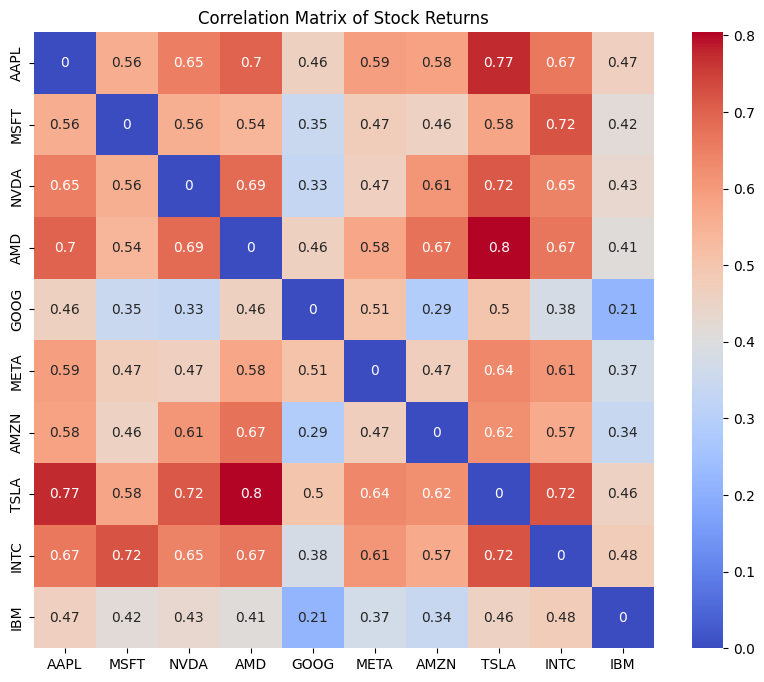

In [128]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

**Graph Filter**

In [129]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

**Graph Perceptron**

In [130]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y  

**Multi-layer GNN**

In [131]:
class MLGNN(nn.Module):
    def __init__(self, gso, l, k, sigma):
        super().__init__()
        layers = []
        for layer in range(l):
            if layer < l - 1:
                layers.append(graph_perceptron(gso, k[layer], sigma))
            else:
                layers.append(graph_perceptron(gso, k[layer], nn.Identity()))  # no activation on last layer
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y = self.layers(x)
        return y

**Multiple Feature Filters and GNNs**

In [132]:
def FilterFunctionMulti(h, S, x):
    
    # we assume that the input x PyTorch tensor [B, G, N]
    # the output is y PyTorch tensor [B, F, N]
    # Number of output features
    F = h.shape[0]
    
    # Number of filter taps
    K = h.shape[1]
    
    # Number of input features
    G = h.shape[2]
    
    # Number of nodes
    N = S.shape[1]
    
    # Batch size
    B = x.shape[0]

    # Create concatenation dimension and initialize concatenation tensor z
    x = x.reshape([B, 1, G, N])
    S = S.reshape([1, N, N])
    z = x
    
    # Loop over the number of filter taps
    for k in range(1, K):
        
        # S*x
        x = torch.matmul(x, S)
        
        # Reshape
        xS = x.reshape([B, 1, G, N])
        
        # Concatenate
        z = torch.cat((z, xS), dim=1)
    
    # Multiply by h
    y = torch.matmul(z.permute(0, 3, 1, 2).reshape([B, N, K*G]), 
                     h.reshape([F, K*G]).permute(1, 0)).permute(0, 2, 1)
    return y
    
    
class GraphFilterMulti(nn.Module):
    def __init__(self, gso, k, f_in, f_out):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.f_in = f_in
        self.f_out = f_out
        self.weight = nn.Parameter(torch.randn(self.f_out, self.k, self.f_in))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.f_in * self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return FilterFunctionMulti(self.weight, self.gso, x)

In [133]:
class GNNMulti(nn.Module):
    def __init__(self, gso, l, k, f, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.l = l
        self.k = k
        self.f = f
        self.sigma = sigma
        
        gml = []
        for layer in range(l):
            gml.append(GraphFilterMulti(gso, k[layer], f[layer], f[layer+1]))
            if layer < l - 1:  # no activation after last layer
                gml.append(sigma)
        
        self.gml = nn.Sequential(*gml)
        
    def forward(self, x):
        return self.gml(x)

**TESTING**

In [134]:
def train_model(model, x_train, y_train, lr=0.01, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1} with loss {loss.item():.6f}")
            break
    return model, losses

In [135]:
def train_model_multi(model, x_train, y_train, lr=0.001, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train).squeeze(1)  # (B, 1, N) --> (B, N)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1}")
            break
    return model, losses

/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/3586927298.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)


Training Graph Filter...
Epoch 10/300, Loss: 0.123919
Epoch 20/300, Loss: 0.081177
Epoch 30/300, Loss: 0.048662
Epoch 40/300, Loss: 0.026867
Epoch 50/300, Loss: 0.013635
Epoch 60/300, Loss: 0.006356
Epoch 70/300, Loss: 0.002852
Epoch 80/300, Loss: 0.001394
Epoch 90/300, Loss: 0.000893
Epoch 100/300, Loss: 0.000760
Epoch 110/300, Loss: 0.000739
Epoch 120/300, Loss: 0.000740
Epoch 130/300, Loss: 0.000740
Epoch 140/300, Loss: 0.000740
Epoch 150/300, Loss: 0.000739
Epoch 160/300, Loss: 0.000739
Epoch 170/300, Loss: 0.000739
Epoch 180/300, Loss: 0.000739
Epoch 190/300, Loss: 0.000739
Epoch 200/300, Loss: 0.000739
Epoch 210/300, Loss: 0.000739
Epoch 220/300, Loss: 0.000739
Epoch 230/300, Loss: 0.000739
Epoch 240/300, Loss: 0.000739
Epoch 250/300, Loss: 0.000739
Epoch 260/300, Loss: 0.000739
Epoch 270/300, Loss: 0.000739
Epoch 280/300, Loss: 0.000739
Epoch 290/300, Loss: 0.000739
Epoch 300/300, Loss: 0.000739


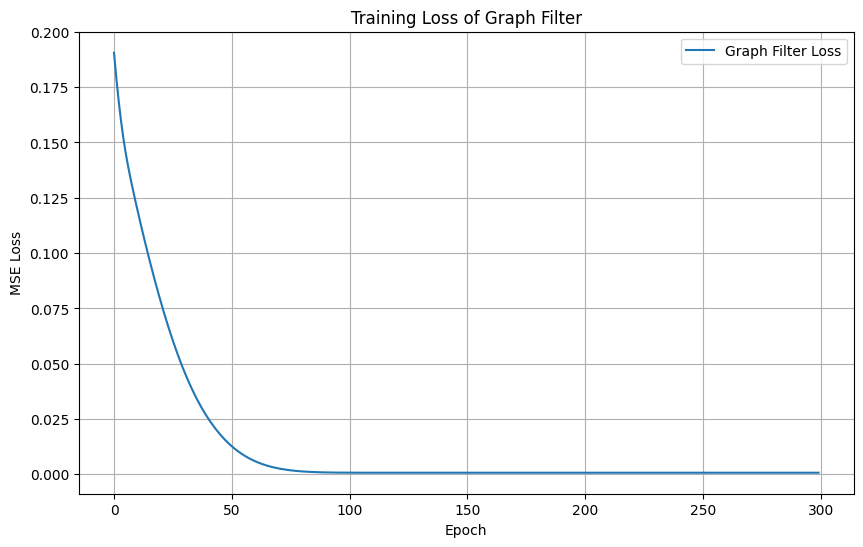

Training Graph Perceptron...
Epoch 10/300, Loss: 0.038504
Epoch 20/300, Loss: 0.029606
Epoch 30/300, Loss: 0.018566
Epoch 40/300, Loss: 0.011609
Epoch 50/300, Loss: 0.006638
Epoch 60/300, Loss: 0.003739
Epoch 70/300, Loss: 0.002095
Epoch 80/300, Loss: 0.001289
Epoch 90/300, Loss: 0.000932
Epoch 100/300, Loss: 0.000795
Epoch 110/300, Loss: 0.000752
Epoch 120/300, Loss: 0.000741
Epoch 130/300, Loss: 0.000739
Epoch 140/300, Loss: 0.000739
Epoch 150/300, Loss: 0.000739
Epoch 160/300, Loss: 0.000739
Epoch 170/300, Loss: 0.000739
Epoch 180/300, Loss: 0.000739
Epoch 190/300, Loss: 0.000739
Epoch 200/300, Loss: 0.000739
Epoch 210/300, Loss: 0.000739
Epoch 220/300, Loss: 0.000739
Epoch 230/300, Loss: 0.000739
Epoch 240/300, Loss: 0.000739
Epoch 250/300, Loss: 0.000739
Epoch 260/300, Loss: 0.000739
Epoch 270/300, Loss: 0.000739
Epoch 280/300, Loss: 0.000739
Epoch 290/300, Loss: 0.000739
Epoch 300/300, Loss: 0.000739


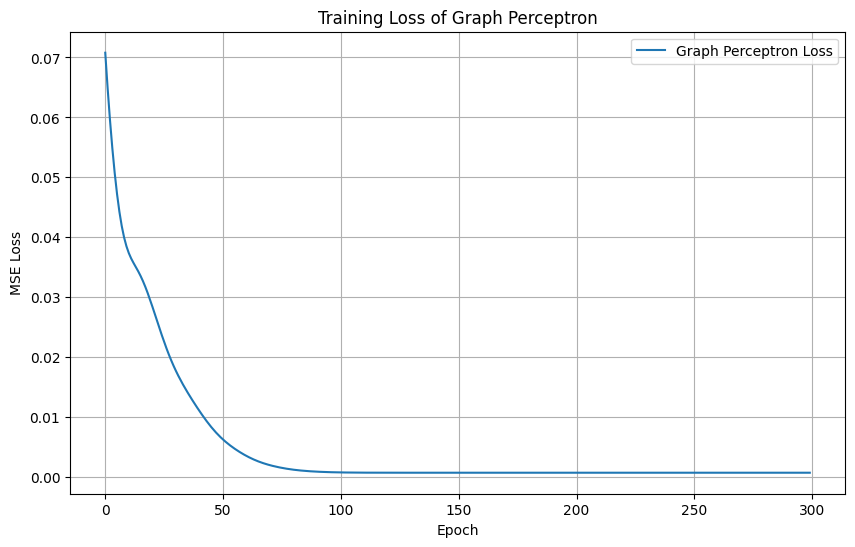

Training MLGNN...
Epoch 10/300, Loss: 0.001222
Epoch 20/300, Loss: 0.000818
Epoch 30/300, Loss: 0.000846
Epoch 40/300, Loss: 0.000839
Epoch 50/300, Loss: 0.000818
Epoch 60/300, Loss: 0.000796
Epoch 70/300, Loss: 0.000779
Epoch 80/300, Loss: 0.000767
Epoch 90/300, Loss: 0.000759
Epoch 100/300, Loss: 0.000754
Epoch 110/300, Loss: 0.000750
Epoch 120/300, Loss: 0.000748
Epoch 130/300, Loss: 0.000746
Epoch 140/300, Loss: 0.000745
Epoch 150/300, Loss: 0.000744
Epoch 160/300, Loss: 0.000743
Epoch 170/300, Loss: 0.000743
Epoch 180/300, Loss: 0.000742
Epoch 190/300, Loss: 0.000742
Epoch 200/300, Loss: 0.000741
Epoch 210/300, Loss: 0.000741
Epoch 220/300, Loss: 0.000741
Epoch 230/300, Loss: 0.000741
Epoch 240/300, Loss: 0.000740
Epoch 250/300, Loss: 0.000740
Epoch 260/300, Loss: 0.000740
Epoch 270/300, Loss: 0.000740
Epoch 280/300, Loss: 0.000740
Epoch 290/300, Loss: 0.000740
Epoch 300/300, Loss: 0.000740


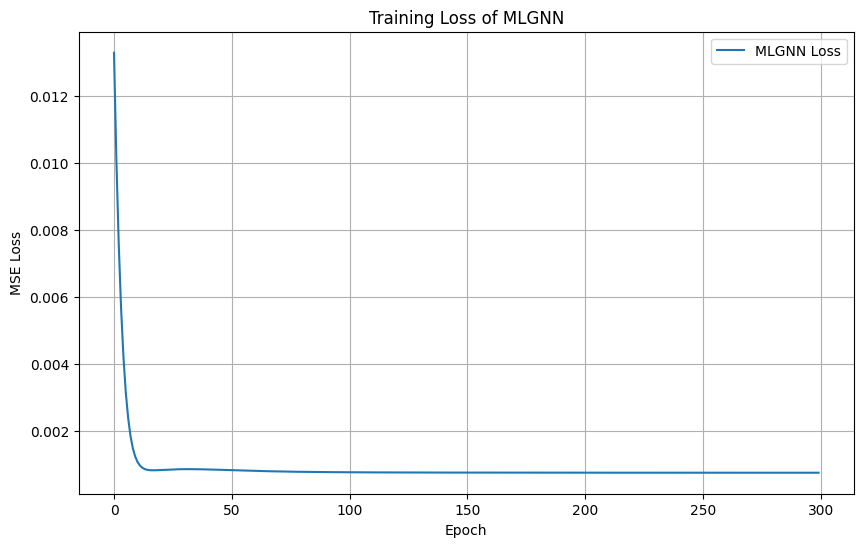

Training Multi Feature Filter...
Epoch 10/300, Loss: 0.161930
Epoch 20/300, Loss: 0.116462
Epoch 30/300, Loss: 0.087499
Epoch 40/300, Loss: 0.066653
Epoch 50/300, Loss: 0.050343
Epoch 60/300, Loss: 0.037692
Epoch 70/300, Loss: 0.028108
Epoch 80/300, Loss: 0.020990
Epoch 90/300, Loss: 0.015789
Epoch 100/300, Loss: 0.012038
Epoch 110/300, Loss: 0.009361
Epoch 120/300, Loss: 0.007459
Epoch 130/300, Loss: 0.006100
Epoch 140/300, Loss: 0.005116
Epoch 150/300, Loss: 0.004388
Epoch 160/300, Loss: 0.003835
Epoch 170/300, Loss: 0.003403
Epoch 180/300, Loss: 0.003058
Epoch 190/300, Loss: 0.002777
Epoch 200/300, Loss: 0.002544
Epoch 210/300, Loss: 0.002350
Epoch 220/300, Loss: 0.002186
Epoch 230/300, Loss: 0.002049
Epoch 240/300, Loss: 0.001932
Epoch 250/300, Loss: 0.001834
Epoch 260/300, Loss: 0.001750
Epoch 270/300, Loss: 0.001678
Epoch 280/300, Loss: 0.001617
Epoch 290/300, Loss: 0.001565
Epoch 300/300, Loss: 0.001520


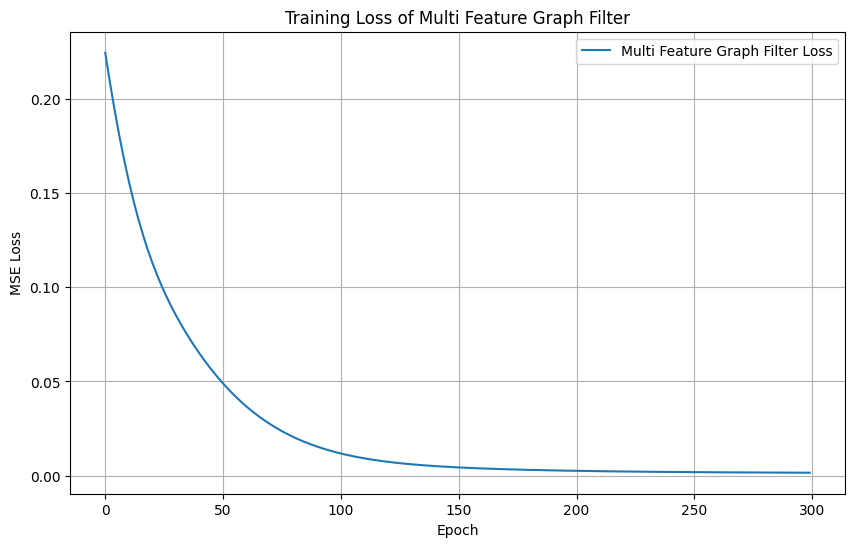

Training Multi Feature GNN...
Epoch 10/300, Loss: 0.006626
Epoch 20/300, Loss: 0.006033
Epoch 30/300, Loss: 0.002645
Epoch 40/300, Loss: 0.002236
Epoch 50/300, Loss: 0.001637
Epoch 60/300, Loss: 0.001489
Epoch 70/300, Loss: 0.001349
Epoch 80/300, Loss: 0.001260
Epoch 90/300, Loss: 0.001196
Epoch 100/300, Loss: 0.001143
Epoch 110/300, Loss: 0.001100
Epoch 120/300, Loss: 0.001064
Epoch 130/300, Loss: 0.001033
Epoch 140/300, Loss: 0.001005
Epoch 150/300, Loss: 0.000981
Epoch 160/300, Loss: 0.000960
Epoch 170/300, Loss: 0.000941
Epoch 180/300, Loss: 0.000924
Epoch 190/300, Loss: 0.000909
Epoch 200/300, Loss: 0.000895
Epoch 210/300, Loss: 0.000882
Epoch 220/300, Loss: 0.000870
Epoch 230/300, Loss: 0.000859
Epoch 240/300, Loss: 0.000849
Epoch 250/300, Loss: 0.000840
Epoch 260/300, Loss: 0.000831
Epoch 270/300, Loss: 0.000823
Epoch 280/300, Loss: 0.000816
Epoch 290/300, Loss: 0.000809
Epoch 300/300, Loss: 0.000803


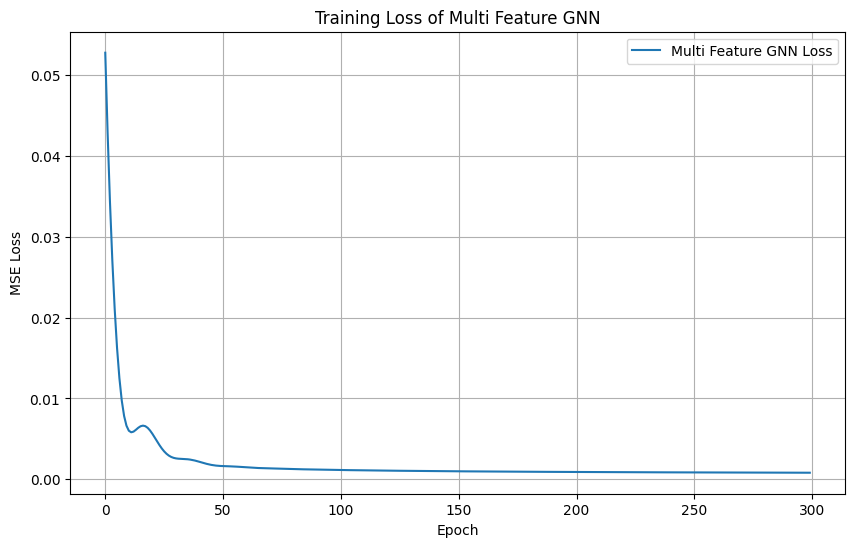

Training Multi Feature GNN with Partial Correlation Graph...
Epoch 10/300, Loss: 0.007893
Epoch 20/300, Loss: 0.004335
Epoch 30/300, Loss: 0.002575
Epoch 40/300, Loss: 0.002116
Epoch 50/300, Loss: 0.001722
Epoch 60/300, Loss: 0.001531
Epoch 70/300, Loss: 0.001402
Epoch 80/300, Loss: 0.001313
Epoch 90/300, Loss: 0.001241
Epoch 100/300, Loss: 0.001185
Epoch 110/300, Loss: 0.001137
Epoch 120/300, Loss: 0.001097
Epoch 130/300, Loss: 0.001062
Epoch 140/300, Loss: 0.001032
Epoch 150/300, Loss: 0.001007
Epoch 160/300, Loss: 0.000984
Epoch 170/300, Loss: 0.000964
Epoch 180/300, Loss: 0.000946
Epoch 190/300, Loss: 0.000930
Epoch 200/300, Loss: 0.000916
Epoch 210/300, Loss: 0.000903
Epoch 220/300, Loss: 0.000891
Epoch 230/300, Loss: 0.000880
Epoch 240/300, Loss: 0.000871
Epoch 250/300, Loss: 0.000862
Epoch 260/300, Loss: 0.000854
Epoch 270/300, Loss: 0.000846
Epoch 280/300, Loss: 0.000839
Epoch 290/300, Loss: 0.000832
Epoch 300/300, Loss: 0.000826


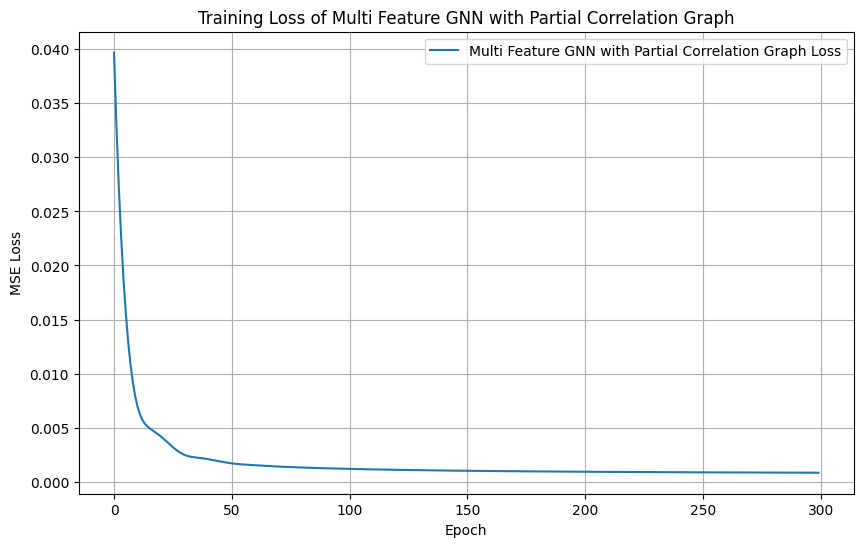

Training Multi Feature GNN with Thresholded Correlation Graph...
Epoch 10/300, Loss: 0.004937
Epoch 20/300, Loss: 0.002674
Epoch 30/300, Loss: 0.001807
Epoch 40/300, Loss: 0.001432
Epoch 50/300, Loss: 0.001243
Epoch 60/300, Loss: 0.001135
Epoch 70/300, Loss: 0.001065
Epoch 80/300, Loss: 0.001018
Epoch 90/300, Loss: 0.000983
Epoch 100/300, Loss: 0.000954
Epoch 110/300, Loss: 0.000930
Epoch 120/300, Loss: 0.000910
Epoch 130/300, Loss: 0.000893
Epoch 140/300, Loss: 0.000878
Epoch 150/300, Loss: 0.000865
Epoch 160/300, Loss: 0.000853
Epoch 170/300, Loss: 0.000842
Epoch 180/300, Loss: 0.000833
Epoch 190/300, Loss: 0.000824
Epoch 200/300, Loss: 0.000816
Epoch 210/300, Loss: 0.000809
Epoch 220/300, Loss: 0.000803
Epoch 230/300, Loss: 0.000797
Epoch 240/300, Loss: 0.000791
Epoch 250/300, Loss: 0.000786
Epoch 260/300, Loss: 0.000781
Epoch 270/300, Loss: 0.000777
Epoch 280/300, Loss: 0.000773
Epoch 290/300, Loss: 0.000769
Epoch 300/300, Loss: 0.000765


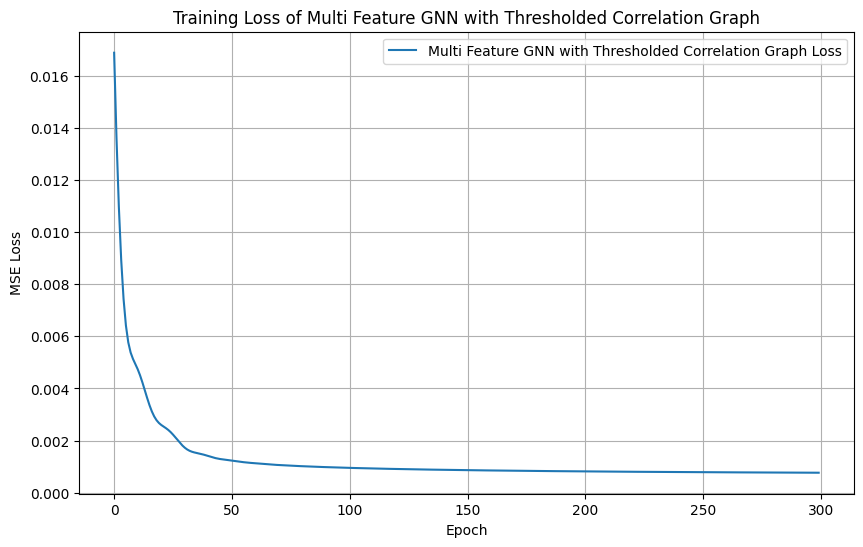

Training Multi Feature GNN with Full Correlation Graph...
Epoch 10/300, Loss: 0.003169
Epoch 20/300, Loss: 0.002389
Epoch 30/300, Loss: 0.001590
Epoch 40/300, Loss: 0.001316
Epoch 50/300, Loss: 0.001175
Epoch 60/300, Loss: 0.001071
Epoch 70/300, Loss: 0.001009
Epoch 80/300, Loss: 0.000962
Epoch 90/300, Loss: 0.000929
Epoch 100/300, Loss: 0.000902
Epoch 110/300, Loss: 0.000880
Epoch 120/300, Loss: 0.000862
Epoch 130/300, Loss: 0.000846
Epoch 140/300, Loss: 0.000833
Epoch 150/300, Loss: 0.000820
Epoch 160/300, Loss: 0.000810
Epoch 170/300, Loss: 0.000800
Epoch 180/300, Loss: 0.000791
Epoch 190/300, Loss: 0.000783
Epoch 200/300, Loss: 0.000775
Epoch 210/300, Loss: 0.000768
Epoch 220/300, Loss: 0.000761
Epoch 230/300, Loss: 0.000755
Epoch 240/300, Loss: 0.000750
Epoch 250/300, Loss: 0.000745
Epoch 260/300, Loss: 0.000740
Epoch 270/300, Loss: 0.000735
Epoch 280/300, Loss: 0.000731
Epoch 290/300, Loss: 0.000727
Epoch 300/300, Loss: 0.000724


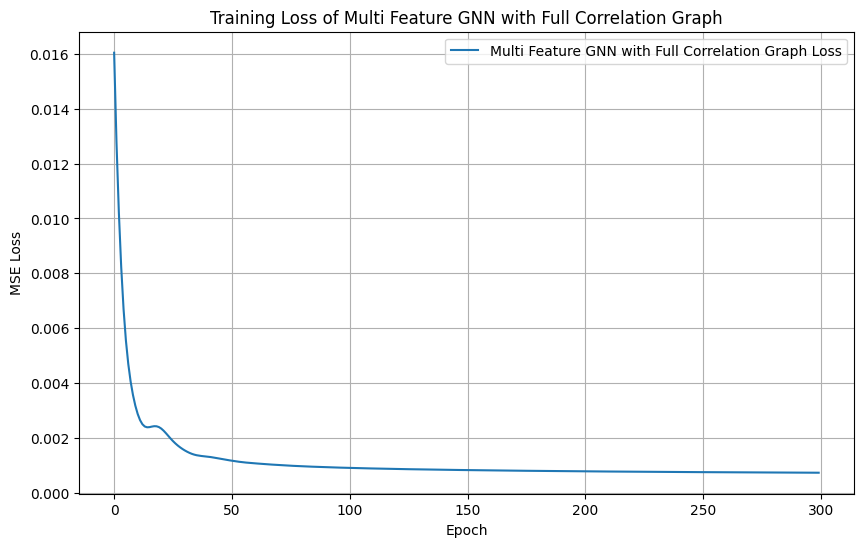

Training Multi Feature GNN with No Correlation Graph...
Epoch 10/300, Loss: 0.001463
Epoch 20/300, Loss: 0.001178
Epoch 30/300, Loss: 0.000955
Epoch 40/300, Loss: 0.000884
Epoch 50/300, Loss: 0.000825
Epoch 60/300, Loss: 0.000804
Epoch 70/300, Loss: 0.000787
Epoch 80/300, Loss: 0.000777
Epoch 90/300, Loss: 0.000769
Epoch 100/300, Loss: 0.000764
Epoch 110/300, Loss: 0.000760
Epoch 120/300, Loss: 0.000757
Epoch 130/300, Loss: 0.000754
Epoch 140/300, Loss: 0.000752
Epoch 150/300, Loss: 0.000749
Epoch 160/300, Loss: 0.000747
Epoch 170/300, Loss: 0.000746
Epoch 180/300, Loss: 0.000744
Epoch 190/300, Loss: 0.000743
Epoch 200/300, Loss: 0.000741
Epoch 210/300, Loss: 0.000740
Epoch 220/300, Loss: 0.000739
Epoch 230/300, Loss: 0.000737
Epoch 240/300, Loss: 0.000736
Epoch 250/300, Loss: 0.000735
Epoch 260/300, Loss: 0.000734
Epoch 270/300, Loss: 0.000733
Epoch 280/300, Loss: 0.000732
Epoch 290/300, Loss: 0.000731
Epoch 300/300, Loss: 0.000730


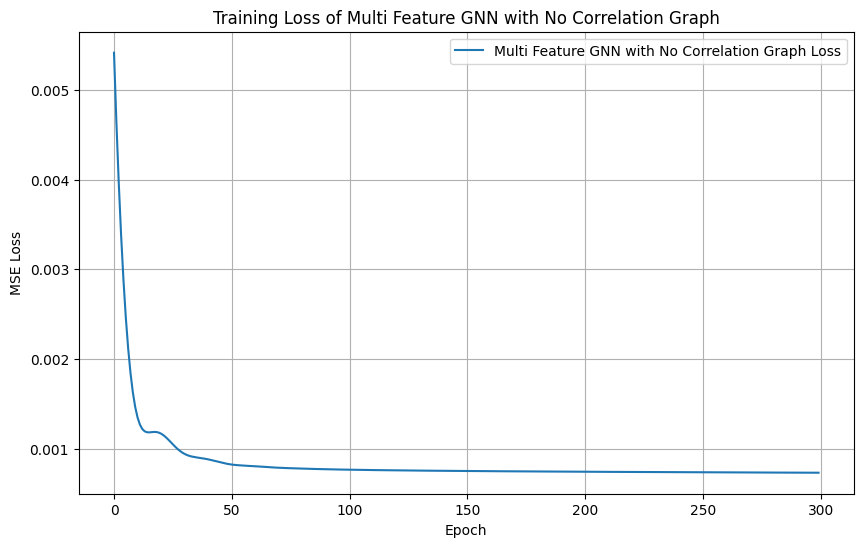

In [140]:
corr = stock_graph(y_train)
corr = normalize_graph(corr)
corr = torch.tensor(corr, dtype=torch.float32)
# print("Correlation:", corr)

# alternative graph constructions
partial_corr = partial_corr_graph(y_train)
partial_corr = normalize_graph(partial_corr)
partial_corr = torch.tensor(partial_corr, dtype=torch.float32)
# print("Partial Correlation:", partial_corr)

thresholded_corr = threshold_graph(corr, threshold=0.5)
thresholded_corr = normalize_graph(thresholded_corr)
thresholded_corr = torch.tensor(thresholded_corr, dtype=torch.float32)
# print("Thresholded Correlation:", thresholded_corr)

full_corr = full_correlation_graph(y_train)
full_corr = normalize_graph(full_corr)
full_corr = torch.tensor(full_corr, dtype=torch.float32)
# print("Full Correlation Graph:", full_corr)

no_corr = no_correlation_graph(y_train)
no_corr = normalize_graph(no_corr)
no_corr = torch.tensor(no_corr, dtype=torch.float32)
# print("No Correlation Graph:", no_corr)


# compute statistics from training data!
x_mean = x_train_tensor.mean(dim=0)
x_std  = x_train_tensor.std(dim=0) + 1e-8

x_train_tensor_norm = (x_train_tensor - x_mean) / x_std
x_test_tensor_norm  = (x_test_tensor  - x_mean) / x_std

x_muli_feature_train = x_train_tensor_norm.unsqueeze(1) # shape [B, 1, N]
x_muli_feature_test = x_test_tensor_norm.unsqueeze(1) # shape [B, 1, N]

K = 3
gf_model = graph_filter(corr, K)
gp_model = graph_perceptron(corr, K, nn.ReLU())
mlgnn_model = MLGNN(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU())
mfgf_model = GraphFilterMulti(corr, k=3, f_in=10, f_out=1)
mfgnn_model = GNNMulti(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])

mfgnn_model_partial = GNNMulti(partial_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])
mfgnn_model_thresholded = GNNMulti(thresholded_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])
mfgnn_model_full_corr = GNNMulti(full_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])
mfgnn_model_no_corr = GNNMulti(no_corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[10, 32, 1])

print("Training Graph Filter...")
gf_model, gf_losses = train_model(gf_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for graph filter
plt.figure(figsize=(10, 6))
plt.plot(gf_losses, label='Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Filter')
plt.legend()
plt.grid()
plt.show()

print("Training Graph Perceptron...")
gp_model, gp_losses = train_model(gp_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for graph perceptron
plt.figure(figsize=(10, 6))
plt.plot(gp_losses, label='Graph Perceptron Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Perceptron')
plt.legend()
plt.grid()
plt.show()

print("Training MLGNN...")
mlgnn_model, mlgnn_losses = train_model(mlgnn_model, x_train_tensor_norm, y_train_tensor)
# plot loss per epoch for MLGNN
plt.figure(figsize=(10, 6))
plt.plot(mlgnn_losses, label='MLGNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of MLGNN')
plt.legend()
plt.grid()
plt.show()


print("Training Multi Feature Filter...")
mfgf_model, mfgf_losses = train_model_multi(mfgf_model, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature graph filter
plt.figure(figsize=(10, 6))
plt.plot(mfgf_losses, label='Multi Feature Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature Graph Filter')
plt.legend()
plt.grid()
plt.show()


print("Training Multi Feature GNN...")
mfgnn_model, mfgnn_losses = train_model_multi(mfgnn_model, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_losses, label='Multi Feature GNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN')
plt.legend()
plt.grid()
plt.show()

print("Training Multi Feature GNN with Partial Correlation Graph...")
mfgnn_model_partial, mfgnn_partial_losses = train_model_multi(mfgnn_model_partial, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN with partial correlation graph
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_partial_losses, label='Multi Feature GNN with Partial Correlation Graph Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN with Partial Correlation Graph')
plt.legend()
plt.grid()
plt.show()  

print("Training Multi Feature GNN with Thresholded Correlation Graph...")
mfgnn_model_thresholded, mfgnn_thresholded_losses = train_model_multi(mfgnn_model_thresholded, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN with thresholded correlation graph
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_thresholded_losses, label='Multi Feature GNN with Thresholded Correlation Graph Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN with Thresholded Correlation Graph')
plt.legend()
plt.grid()
plt.show()

print("Training Multi Feature GNN with Full Correlation Graph...")
mfgnn_model_full_corr, mfgnn_full_losses = train_model_multi(mfgnn_model_full_corr, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN with full correlation graph
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_full_losses, label='Multi Feature GNN with Full Correlation Graph Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN with Full Correlation Graph')
plt.legend()
plt.grid()
plt.show()

print("Training Multi Feature GNN with No Correlation Graph...")
mfgnn_model_no_corr, mfgnn_no_corr_losses = train_model_multi(mfgnn_model_no_corr, x_train_tensor_mf, y_train_tensor_mf)
# plot loss per epoch for multi feature GNN with no correlation graph
plt.figure(figsize=(10, 6))
plt.plot(mfgnn_no_corr_losses, label='Multi Feature GNN with No Correlation Graph Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Multi Feature GNN with No Correlation Graph')
plt.legend()
plt.grid()
plt.show()


=== Test Results ===
Graph Filter Test Loss: 0.119661
Graph Perceptron Test Loss: 0.000840
MLGNN Test Loss: 0.017147
Multi Feature Graph Filter Test Loss: 0.001593
Multi Feature GNN Test Loss: 0.000845
Multi Feature GNN with Partial Correlation Graph Test Loss: 0.000847
Multi Feature GNN with Thresholded Correlation Graph Test Loss: 0.000769
Multi Feature GNN with Full Correlation Graph Test Loss: 0.000758
Multi Feature GNN with No Correlation Graph Test Loss: 0.000705


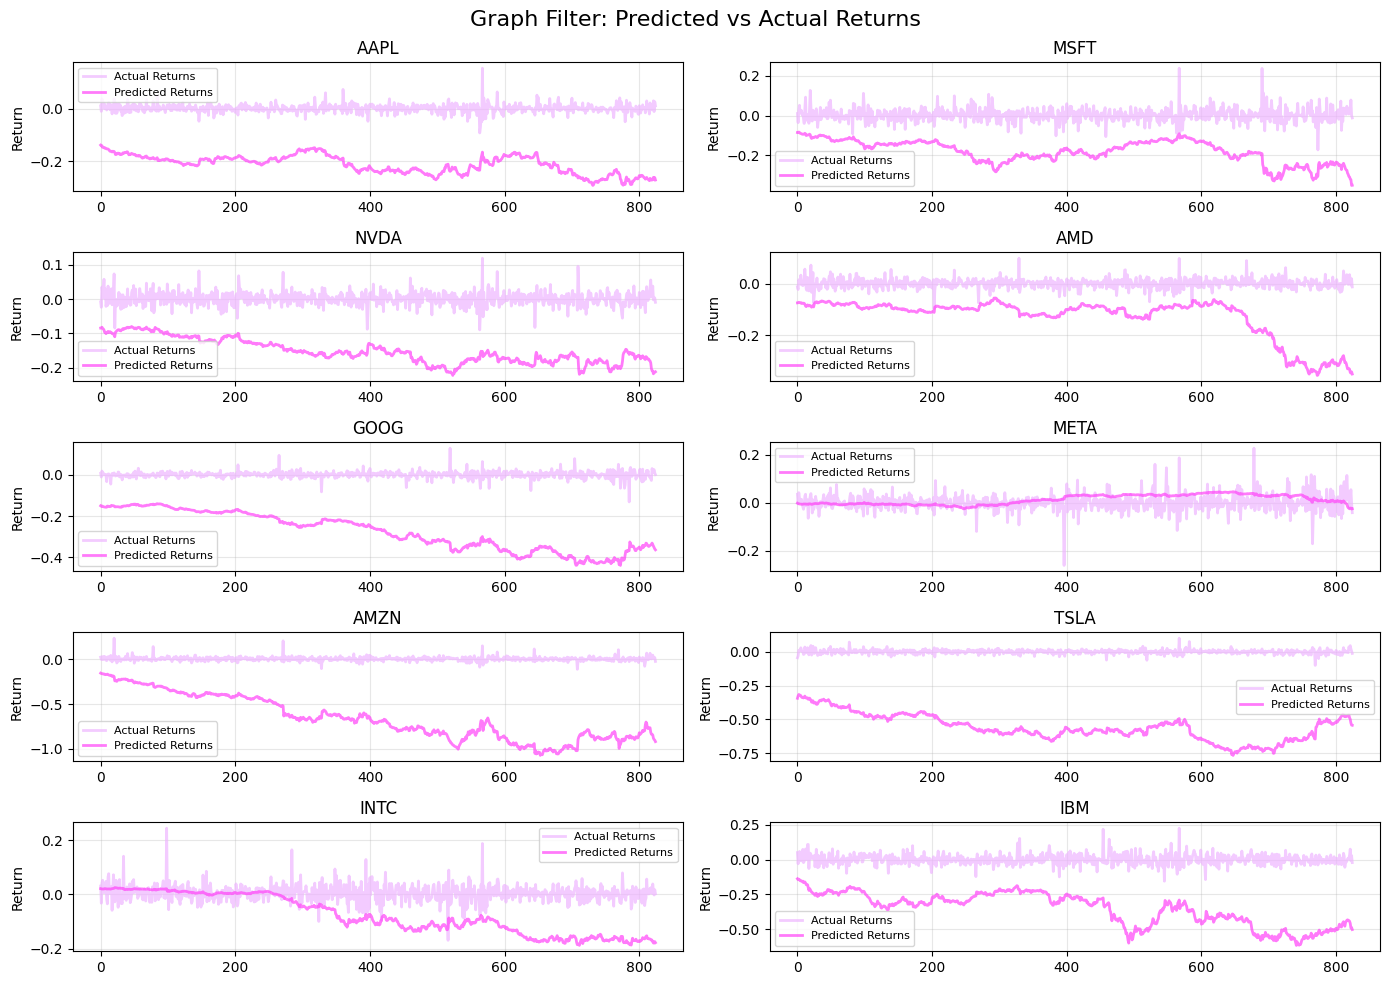

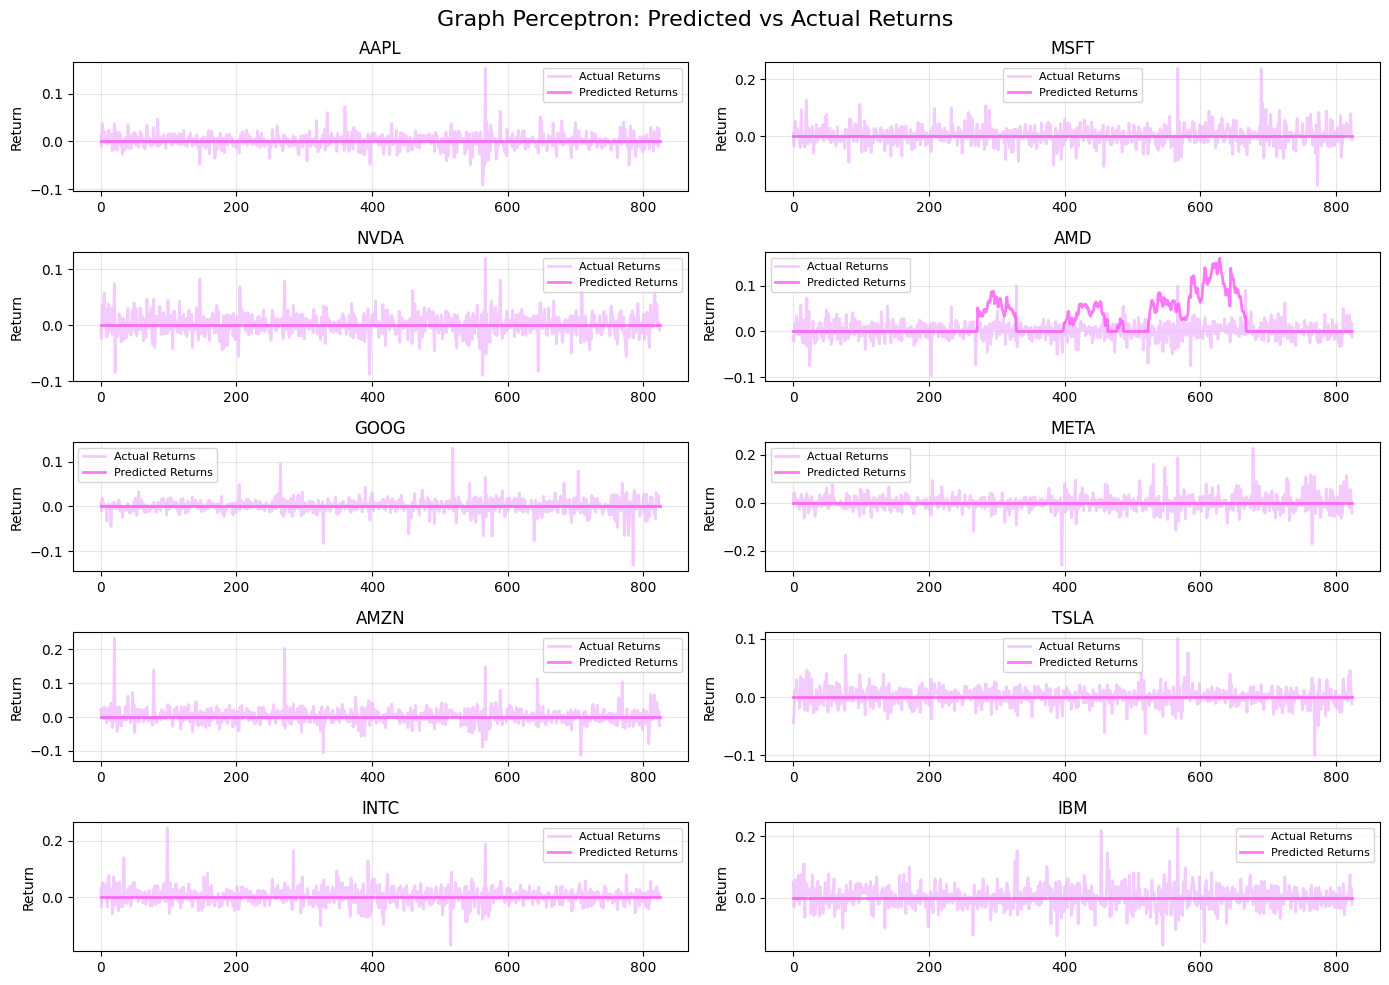

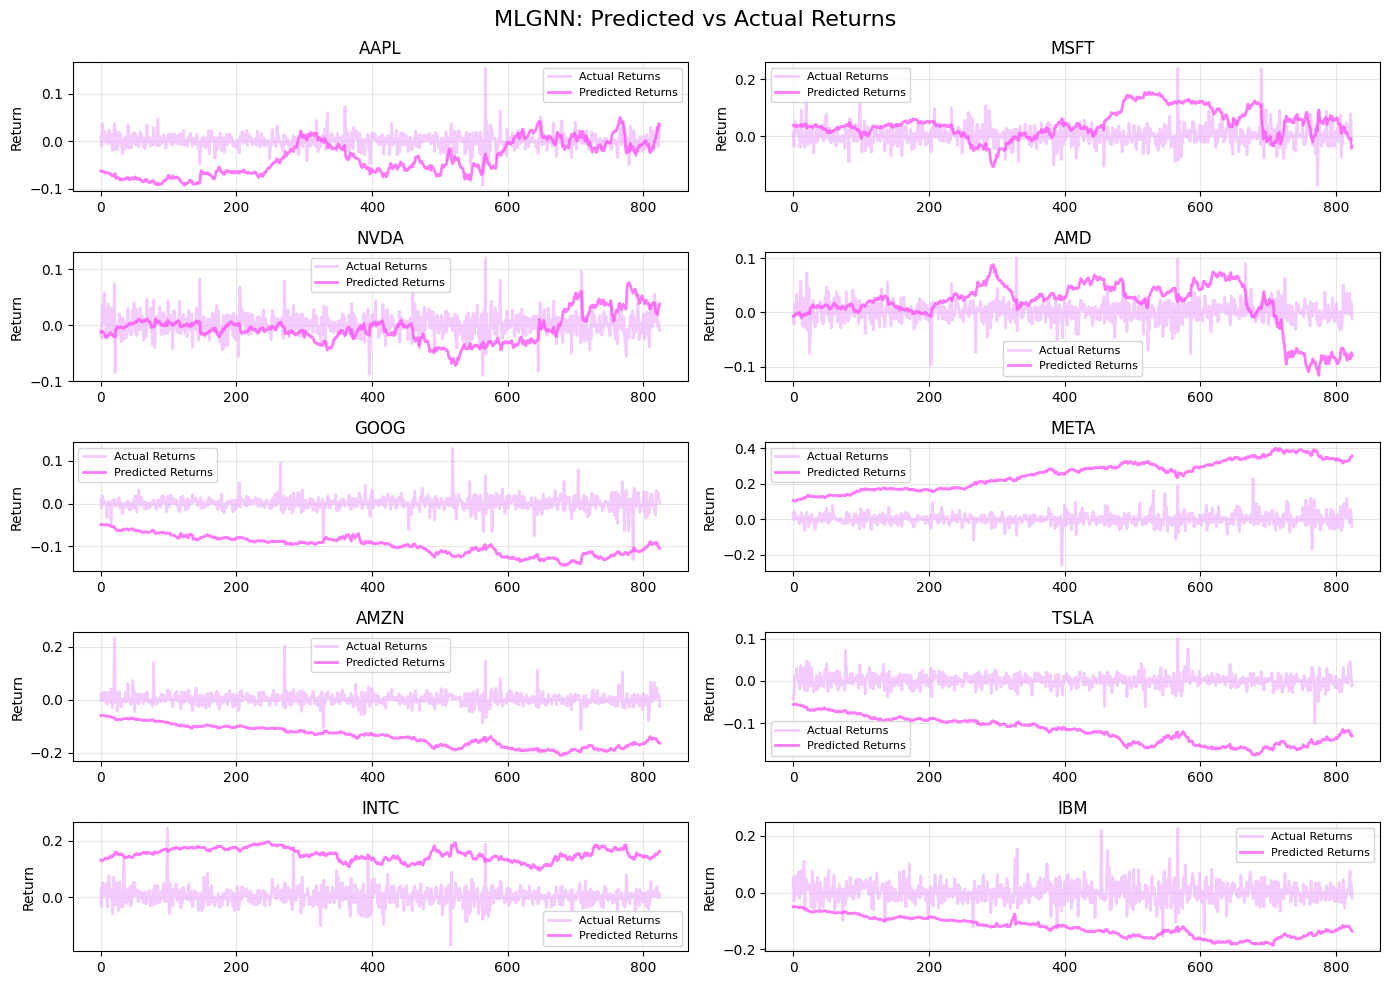

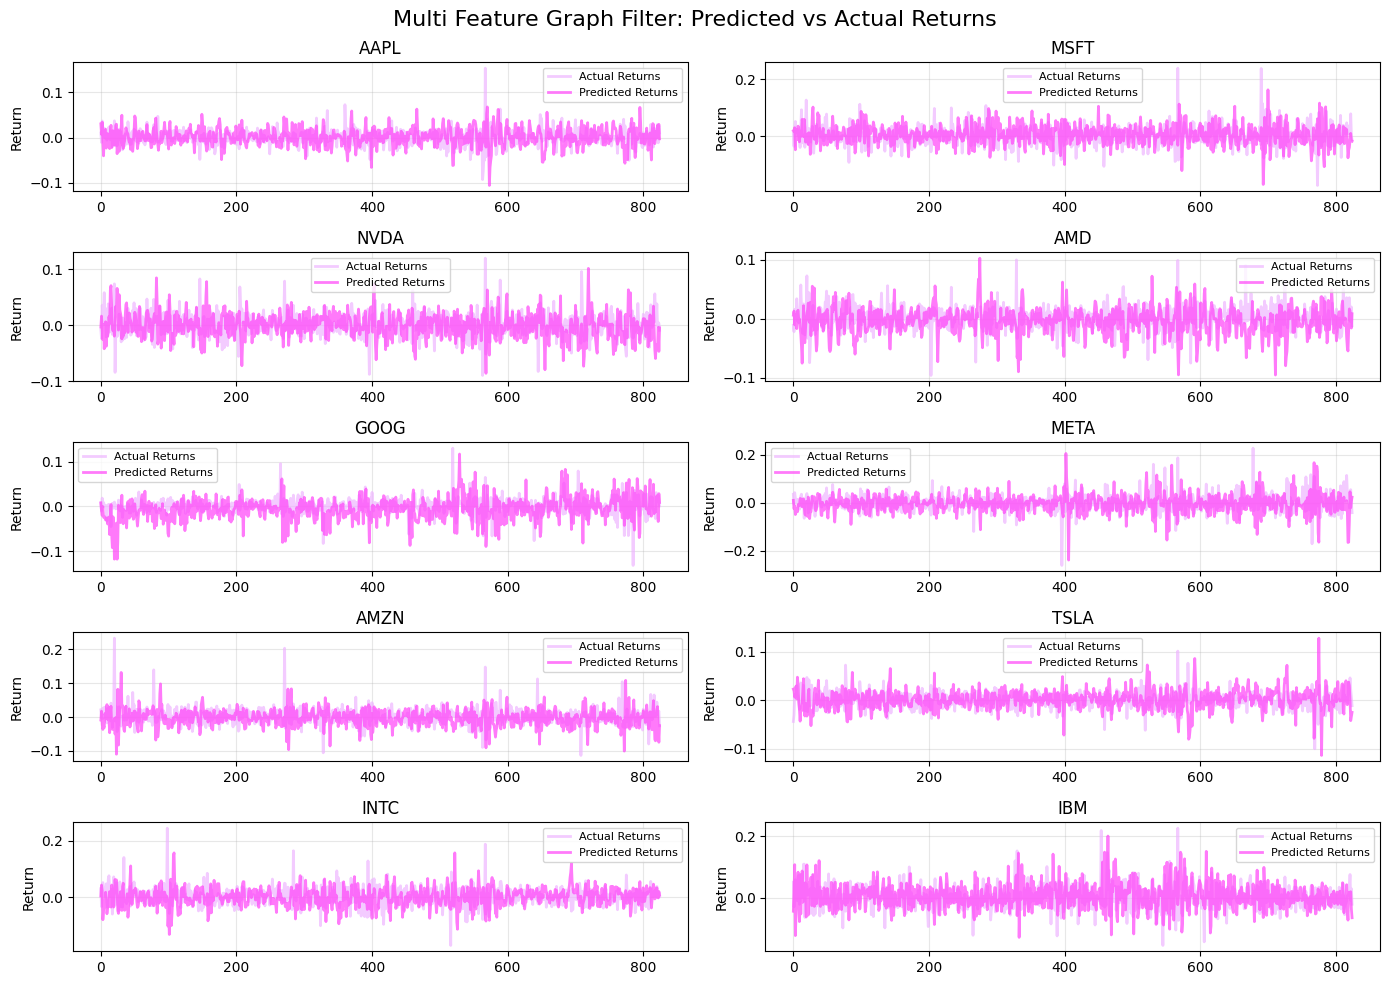

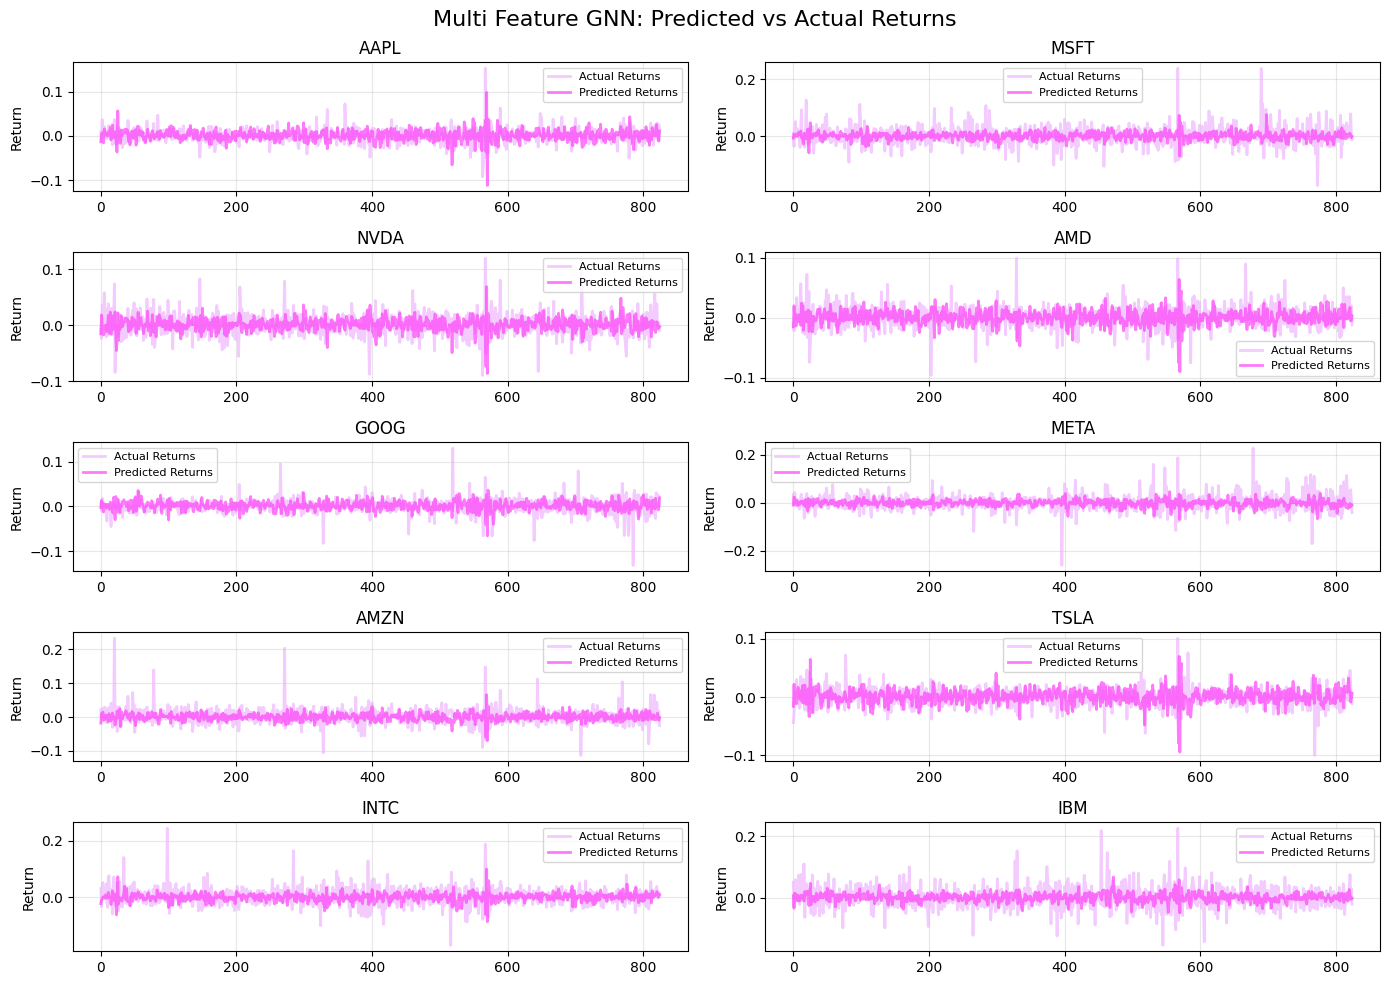

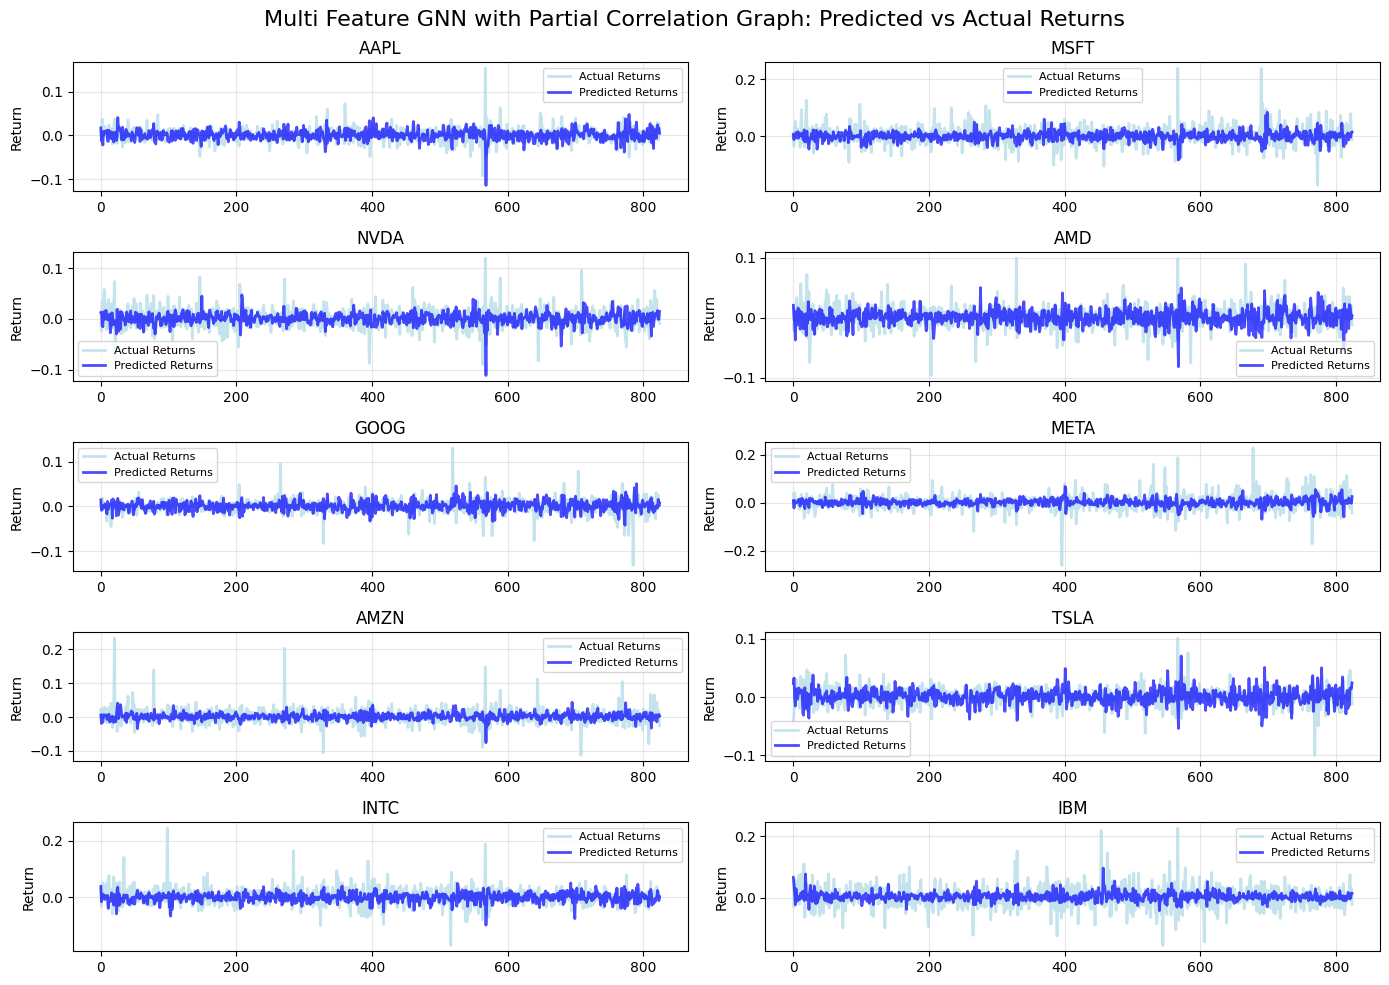

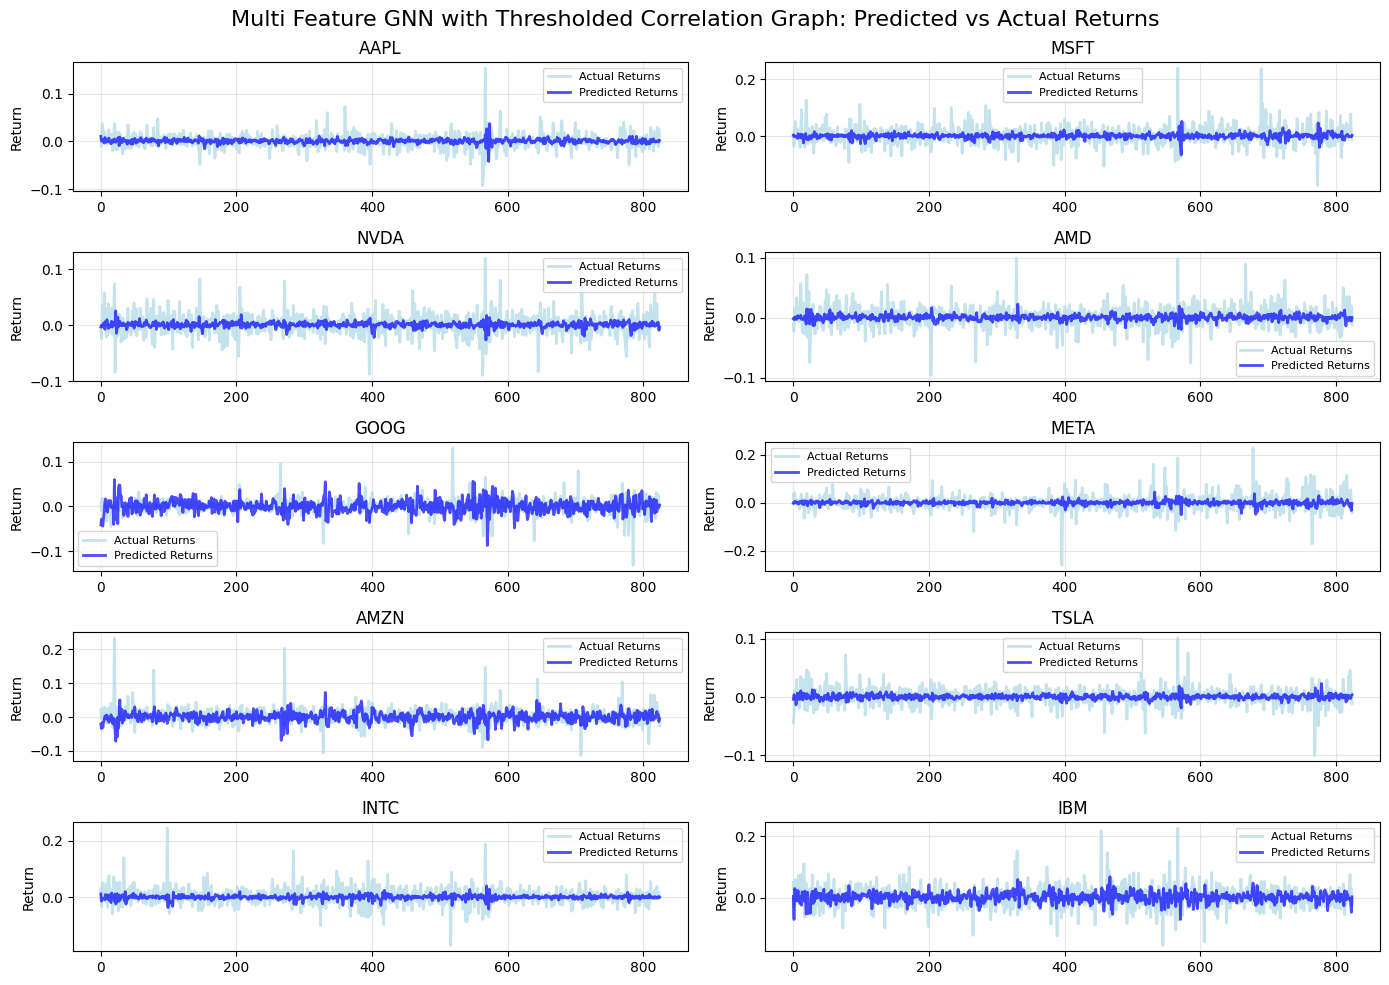

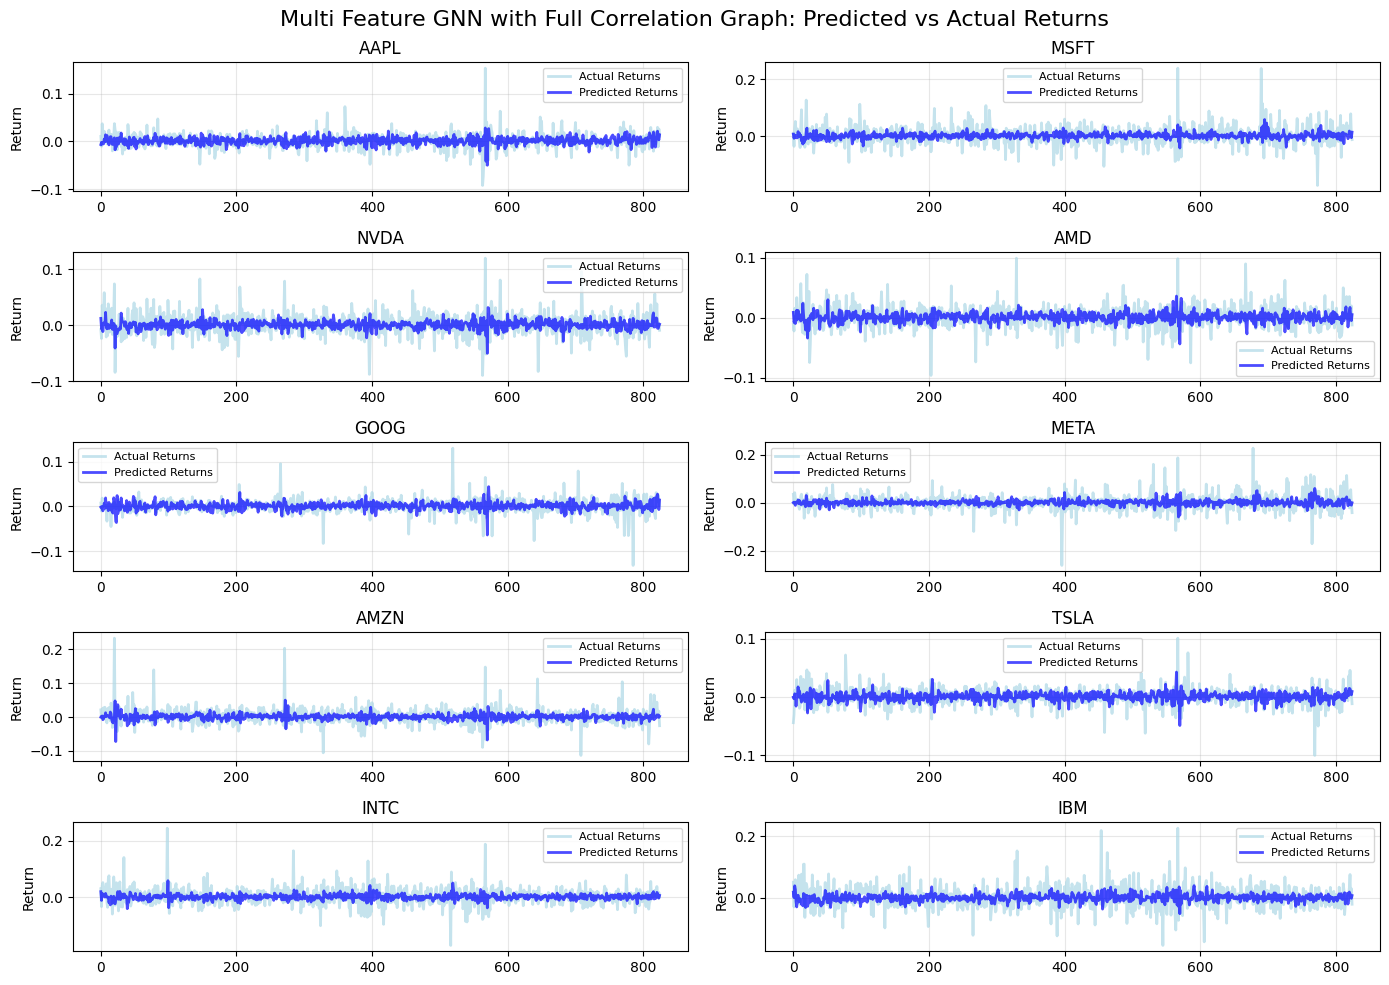

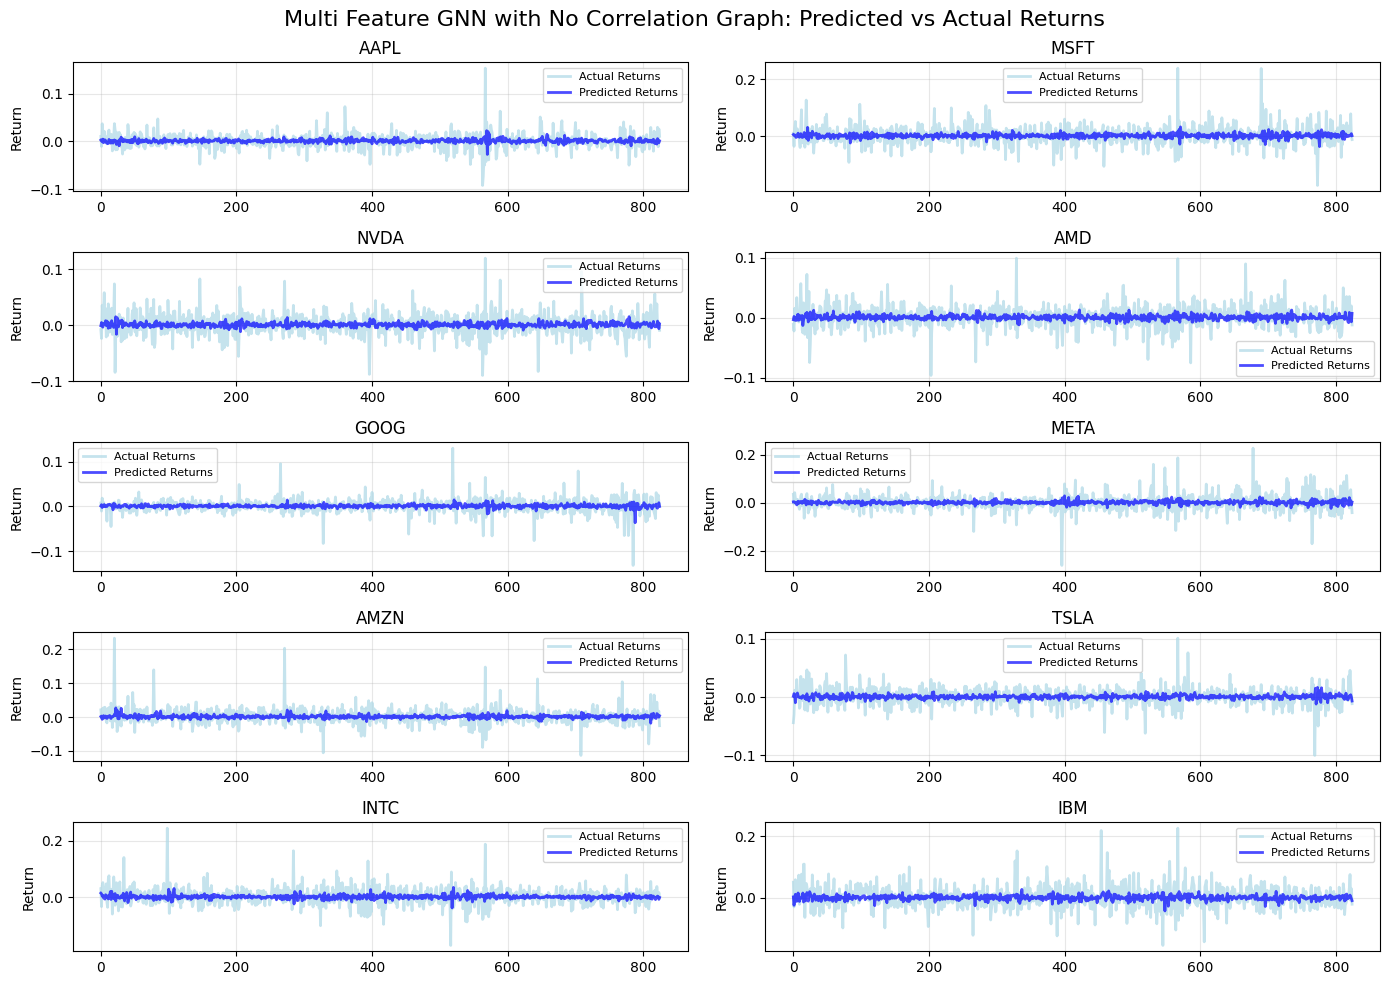

In [153]:
pink = '#ff42f8' 
purple = '#eeb5ff'  

light_blue = '#add8e6'
blue = '#0000ff'

# Evaluate models on test data
criterion = nn.MSELoss()

# Make predictions with both models
with torch.no_grad():
    gf_pred = gf_model(x_test_tensor)
    gp_pred = gp_model(x_test_tensor)
    mlgnn_pred = mlgnn_model(x_test_tensor)
    mfgf_pred = mfgf_model(x_test_tensor_mf).squeeze(1) # reshape from [B, 1, N] to [B, N]
    mfgnn_pred = mfgnn_model(x_test_tensor_mf).squeeze(1) # reshape from [B, 1, N] to [B, N]
    mfgnn_partial_pred = mfgnn_model_partial(x_test_tensor_mf).squeeze(1)
    mfgnn_thresholded_pred = mfgnn_model_thresholded(x_test_tensor_mf).squeeze(1)
    mfgnn_full_corr_pred = mfgnn_model_full_corr(x_test_tensor_mf).squeeze(1)
    mfgnn_no_corr_pred = mfgnn_model_no_corr(x_test_tensor_mf).squeeze(1)

    
    # Compute test loss
    gf_test_loss = criterion(gf_pred, y_test_tensor)
    gp_test_loss = criterion(gp_pred, y_test_tensor)
    mlgnn_test_loss = criterion(mlgnn_pred, y_test_tensor)
    mfgf_test_loss = criterion(mfgf_pred, y_test_tensor_mf)
    mfgnn_test_loss = criterion(mfgnn_pred, y_test_tensor_mf)

    mfgnn_partial_test_loss = criterion(mfgnn_partial_pred, y_test_tensor_mf)
    mfgnn_thresholded_test_loss = criterion(mfgnn_thresholded_pred, y_test_tensor_mf)
    mfgnn_full_corr_test_loss = criterion(mfgnn_full_corr_pred, y_test_tensor_mf)
    mfgnn_no_corr_test_loss = criterion(mfgnn_no_corr_pred, y_test_tensor_mf)

print(f"\n=== Test Results ===")
print(f"Graph Filter Test Loss: {gf_test_loss.item():.6f}")
print(f"Graph Perceptron Test Loss: {gp_test_loss.item():.6f}")
print(f"MLGNN Test Loss: {mlgnn_test_loss.item():.6f}")
print(f"Multi Feature Graph Filter Test Loss: {mfgf_test_loss.item():.6f}")
print(f"Multi Feature GNN Test Loss: {mfgnn_test_loss.item():.6f}")
print(f"Multi Feature GNN with Partial Correlation Graph Test Loss: {mfgnn_partial_test_loss.item():.6f}")
print(f"Multi Feature GNN with Thresholded Correlation Graph Test Loss: {mfgnn_thresholded_test_loss.item():.6f}")
print(f"Multi Feature GNN with Full Correlation Graph Test Loss: {mfgnn_full_corr_test_loss.item():.6f}")
print(f"Multi Feature GNN with No Correlation Graph Test Loss: {mfgnn_no_corr_test_loss.item():.6f}")

# Plot predicted vs actual returns per stock for Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(gf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Graph Perceptron
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Perceptron: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(gp_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for MLGNN
plt.figure(figsize=(14, 10))
plt.suptitle('MLGNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mlgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Mutli Feature Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mfgf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Mutli Feature GNN
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=purple)
    plt.plot(mfgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=pink)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Plot predicted vs actual returns per stock for Multi Feature GNN with Partial Correlation Graph
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN with Partial Correlation Graph: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=light_blue)
    plt.plot(mfgnn_model_partial(x_test_tensor_mf).squeeze(1)[:, i].detach().numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=blue)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show() 


# Plot predicted vs actual returns per stock for Multi Feature GNN with Thresholded Correlation Graph
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN with Thresholded Correlation Graph: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=light_blue)
    plt.plot(mfgnn_model_thresholded(x_test_tensor_mf).squeeze(1)[:, i].detach().numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=blue)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Multi Feature GNN with Full Correlation Graph
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN with Full Correlation Graph: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=light_blue)
    plt.plot(mfgnn_model_full_corr(x_test_tensor_mf).squeeze(1)[:, i].detach().numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=blue)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Plot predicted vs actual returns per stock for Multi Feature GNN with No Correlation Graph
plt.figure(figsize=(14, 10))
plt.suptitle('Multi Feature GNN with No Correlation Graph: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color=light_blue)
    plt.plot(mfgnn_model_no_corr(x_test_tensor_mf).squeeze(1)[:, i].detach().numpy(), label='Predicted Returns', linewidth=2, alpha=0.7, color=blue)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Model Evaluation**

           model      mse  median_mse  std_mse      mae
    Graph Filter 0.000776    0.000183 0.002538 0.019193
Graph Perceptron 0.000687    0.000146 0.002458 0.017558
           MLGNN 0.000689    0.000151 0.002471 0.017622
 MF Graph Filter 0.001593    0.000448 0.003904 0.028690
          MF GNN 0.000845    0.000216 0.002573 0.020315


/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/1493104701.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs = [pearsonr(y_true_np[:, i], y_pred_np[:, i])[0] for i in range(y_true_np.shape[1])]


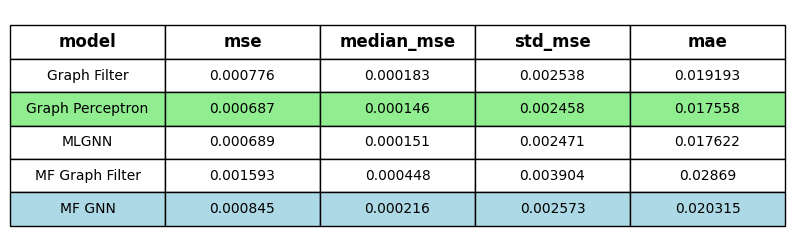

In [167]:
from scipy.stats import pearsonr
import dataframe_image as dfi

with torch.no_grad():
    gf_pred    = gf_model(x_test_tensor_norm)
    gp_pred    = gp_model(x_test_tensor_norm)
    mlgnn_pred = mlgnn_model(x_test_tensor_norm)
    mfgf_pred  = mfgf_model(x_test_tensor_mf).squeeze(1)
    mfgnn_pred = mfgnn_model(x_test_tensor_mf).squeeze(1)


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    median_mse = np.median((y_true_np - y_pred_np) ** 2)
    std_mse = np.std((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    
    # correlation per stock, then average
    corrs = [pearsonr(y_true_np[:, i], y_pred_np[:, i])[0] for i in range(y_true_np.shape[1])]
    avg_corr = np.mean(corrs)
    
    return {
        "mse": float(mse),
        "median_mse": float(median_mse),
        "std_mse": float(std_mse),
        "mae": float(mae)
    }

results = {
    "Graph Filter":       evaluate_metrics(y_test_tensor,  gf_pred),
    "Graph Perceptron":   evaluate_metrics(y_test_tensor,  gp_pred),
    "MLGNN":              evaluate_metrics(y_test_tensor,  mlgnn_pred),
    "MF Graph Filter":    evaluate_metrics(y_test_tensor_mf,   mfgf_pred),
    "MF GNN":             evaluate_metrics(y_test_tensor_mf,   mfgnn_pred),
}

summary = pd.DataFrame(results).T
summary.index.name = "model"
summary = summary.reset_index()
summary.columns = ["model", "mse", "median_mse", "std_mse", "mae"]
print(summary.to_string(index=False))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText=summary.round(6).values,
    colLabels=summary.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# bold column headers
for col_idx in range(len(summary.columns)):
    table[0, col_idx].set_fontsize(12)
    table[0, col_idx].set_text_props(weight='bold')

# highlight best (min) value per numeric column in green
numeric_cols = ["mse", "median_mse", "std_mse", "mae"]

# highlight full Graph Perceptron row (best overall)
mlgnn_row = summary[summary['model'] == 'Graph Perceptron'].index[0]
for col_idx in range(len(summary.columns)):
    table[mlgnn_row + 1, col_idx].set_facecolor("lightgreen")

# highlight full MF GNN row
mfgnn_row = summary[summary['model'] == 'MF GNN'].index[0]
for col_idx in range(len(summary.columns)):
    table[mfgnn_row + 1, col_idx].set_facecolor("lightgreen")

# highlight MF GNN row
mfgnn_row = summary[summary['model'] == 'MF GNN'].index[0]
for col_idx in range(len(summary.columns)):
    table[mfgnn_row + 1, col_idx].set_facecolor("lightblue")

plt.savefig("results_table.png", dpi=200, bbox_inches='tight')
plt.show()

                  model      mse  median_mse  std_mse      mae
    Partial Correlation 0.000847    0.000221 0.002763 0.020313
Thresholded Correlation 0.000769    0.000176 0.002510 0.019019
       Full Correlation 0.000758    0.000181 0.002481 0.018931
         No Correlation 0.000705    0.000153 0.002496 0.017821


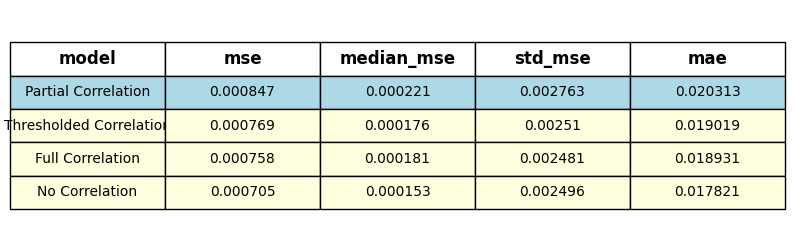

In [168]:
# Evaluate different connectivity schemes for the Multi Feature GNN
connectivity_results = {
    "Partial Correlation": evaluate_metrics(y_test_tensor_mf, mfgnn_model_partial(x_test_tensor_mf).squeeze(1)),
    "Thresholded Correlation": evaluate_metrics(y_test_tensor_mf, mfgnn_model_thresholded(x_test_tensor_mf).squeeze(1)),
    "Full Correlation": evaluate_metrics(y_test_tensor_mf, mfgnn_model_full_corr(x_test_tensor_mf).squeeze(1)),
    "No Correlation": evaluate_metrics(y_test_tensor_mf, mfgnn_model_no_corr(x_test_tensor_mf).squeeze(1)),
}

connectivity_summary = pd.DataFrame(connectivity_results).T
connectivity_summary.index.name = "model"
connectivity_summary = connectivity_summary.reset_index()
connectivity_summary.columns = ["model", "mse", "median_mse", "std_mse", "mae"]
print(connectivity_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(
    cellText=connectivity_summary.round(6).values,
    colLabels=connectivity_summary.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# boid column headers
for col_idx in range(len(connectivity_summary.columns)):
    table[0, col_idx].set_fontsize(12)
    table[0, col_idx].set_text_props(weight='bold')

# highlight full and no correlation rows in yellow
full_row = connectivity_summary[connectivity_summary['model'] == 'Full Correlation'].index[0]
no_row = connectivity_summary[connectivity_summary['model'] == 'No Correlation'].index[0]
partial_row = connectivity_summary[connectivity_summary['model'] == 'Partial Correlation'].index[0]
threshold_row = connectivity_summary[connectivity_summary['model'] == 'Thresholded Correlation'].index[0]
for col_idx in range(len(connectivity_summary.columns)):
    table[full_row + 1, col_idx].set_facecolor("lightyellow")
    table[no_row + 1, col_idx].set_facecolor("lightyellow")
    table[partial_row + 1, col_idx].set_facecolor("lightblue")
    table[threshold_row + 1, col_idx].set_facecolor("lightyellow")


Evaluating best model with feature set: past_5_returns


/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/3107389379.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_66488/2275001755.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)


MF GNN Test Loss with past_5_returns: 0.000857


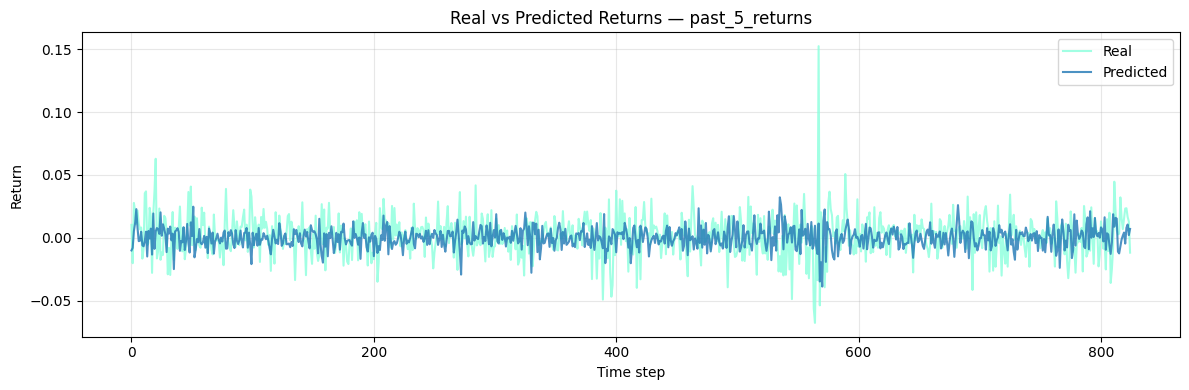


Evaluating best model with feature set: ma
MF GNN Test Loss with ma: 0.000711


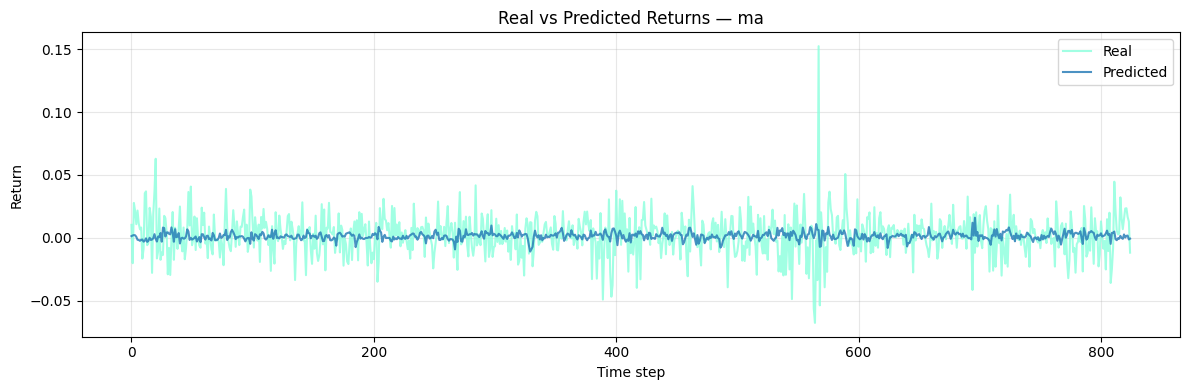


Evaluating best model with feature set: past_5_plus_ma
MF GNN Test Loss with past_5_plus_ma: 0.000778


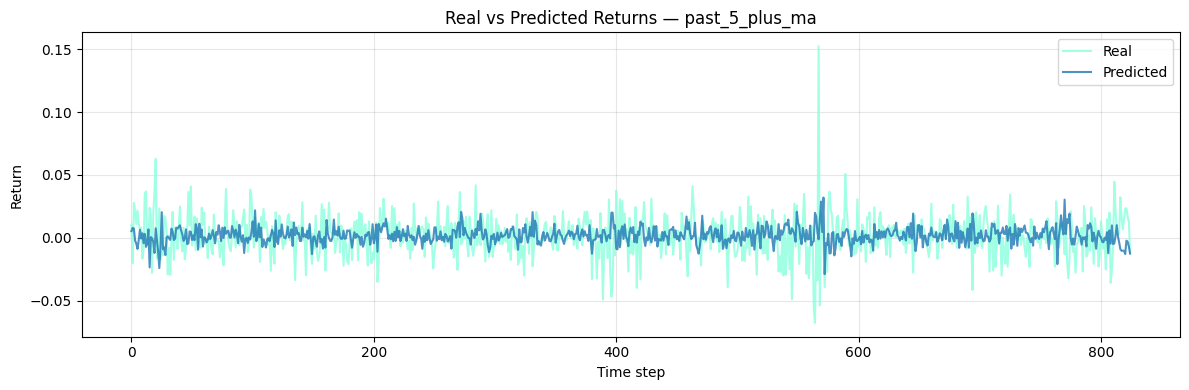


Evaluating best model with feature set: vol5
MF GNN Test Loss with vol5: 0.000703


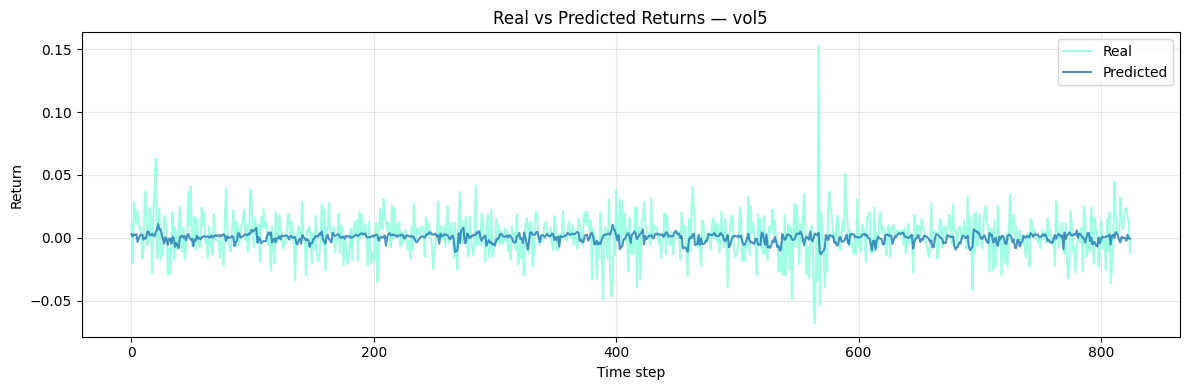


Evaluating best model with feature set: past_5_plus_vol
MF GNN Test Loss with past_5_plus_vol: 0.000762


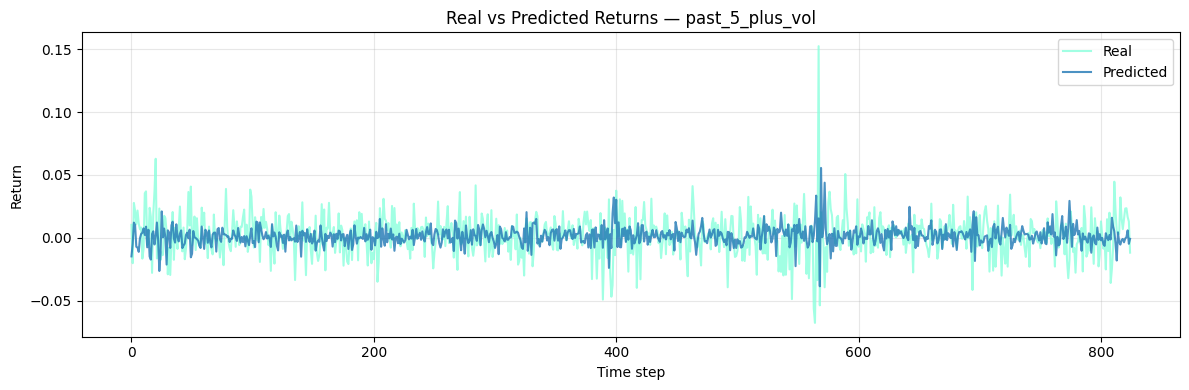


Evaluating best model with feature set: all_features
MF GNN Test Loss with all_features: 0.000839


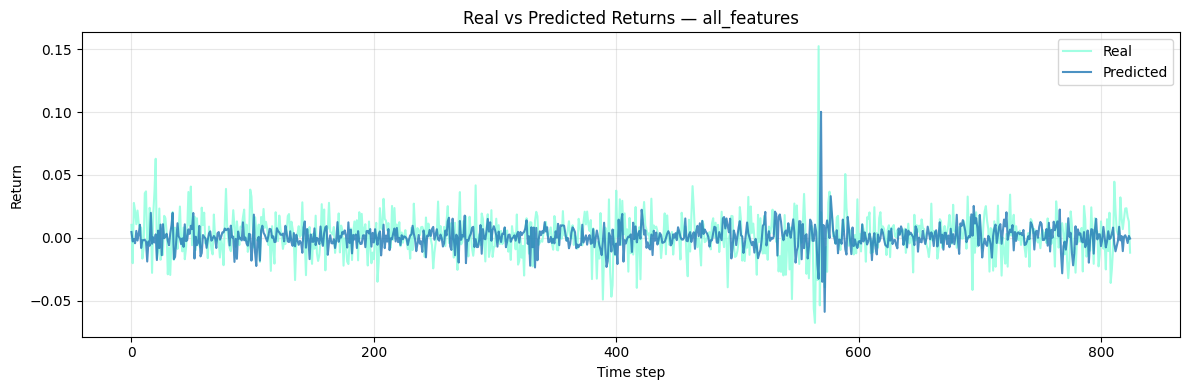

          model      mse  median_mse  std_mse      mae
 past_5_returns 0.000857    0.000230 0.002644 0.020587
             ma 0.000711    0.000157 0.002508 0.018023
 past_5_plus_ma 0.000778    0.000176 0.002614 0.018999
           vol5 0.000703    0.000160 0.002483 0.017970
past_5_plus_vol 0.000762    0.000186 0.002492 0.019040
   all_features 0.000839    0.000206 0.002833 0.019981


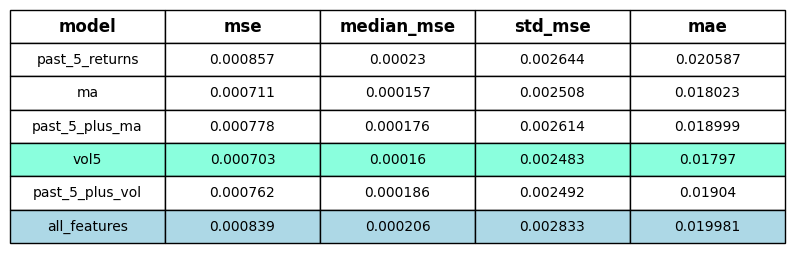

In [170]:
# Evaluate best model with different feature sets
# feature_sets = {
#     "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
#     "ma": ["price_vs_ma_5", "price_vs_ma_10"],
#     "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
#                        "price_vs_ma_5", "price_vs_ma_10"],
#     "vol5": ["vol_5"],
#     "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
#                         "vol_5"],
#     "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
#                      "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
# }

light_green = '#8AFFDD'
green = '#0EB06D'

feature_selection_results = {
    "past_5_returns": [],
    "ma": [],
    "past_5_plus_ma": [],
    "vol5": [],
    "past_5_plus_vol": [],
    "all_features": []
}

for features in feature_sets:
    print(f"\nEvaluating best model with feature set: {features}")
    feature_indices = [feature_names.index(feat) for feat in feature_sets[features]]
    
    X_train_subset = X_train[:, feature_indices, :]
    X_test_subset = X_test[:, feature_indices, :]
    
    X_train_subset_std, X_test_subset_std, _, _ = standardize_panel(X_train_subset, X_test_subset)
    
    x_train_tensor = torch.tensor(X_train_subset_std, dtype=torch.float32)
    x_test_tensor  = torch.tensor(X_test_subset_std,  dtype=torch.float32)

    F_subset = len(feature_indices)

    model = GNNMulti(corr, l=2, k=[3, 3], sigma=nn.LeakyReLU(), f=[F_subset, 32, 1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(301):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train_tensor).squeeze(1)
        loss = criterion(pred, y_train_tensor_mf)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(x_test_tensor).squeeze(1)
        loss = criterion(pred, y_test_tensor_mf)
    print(f"MF GNN Test Loss with {features}: {loss.item():.6f}")

    y_true_np = y_test_tensor_mf.detach().cpu().numpy()
    y_pred_np = pred.detach().cpu().numpy()

    y_true_mean = y_true_np.mean(axis=1)
    y_pred_mean = y_pred_np.mean(axis=1)

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_mean, label='Real', alpha=0.8, color=light_green)
    plt.plot(y_pred_mean, label='Predicted', alpha=0.8)
    plt.title(f'Real vs Predicted Returns — {features}')
    plt.xlabel('Time step')
    plt.ylabel('Return')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'pred_vs_real_{features}.png', dpi=150, bbox_inches='tight')
    plt.show()

    feature_selection_results[features] = evaluate_metrics(y_test_tensor_mf, pred)

features_summary = pd.DataFrame(feature_selection_results).T
features_summary.index.name = "model"
features_summary = features_summary.reset_index()
features_summary.columns = ["model", "mse", "median_mse", "std_mse", "mae"]
print(features_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(
    cellText=features_summary.round(6).values,
    colLabels=features_summary.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# boid column headers
for col_idx in range(len(features_summary.columns)):
    table[0, col_idx].set_fontsize(12)
    table[0, col_idx].set_text_props(weight='bold')

# highlight volatility and all features rows in green
vol_row = features_summary[features_summary['model'] == 'vol5'].index[0]
all_row = features_summary[features_summary['model'] == 'all_features'].index[0]
for col_idx in range(len(features_summary.columns)):
    table[vol_row + 1, col_idx].set_facecolor(light_green)
    table[all_row + 1, col_idx].set_facecolor(light_blue)

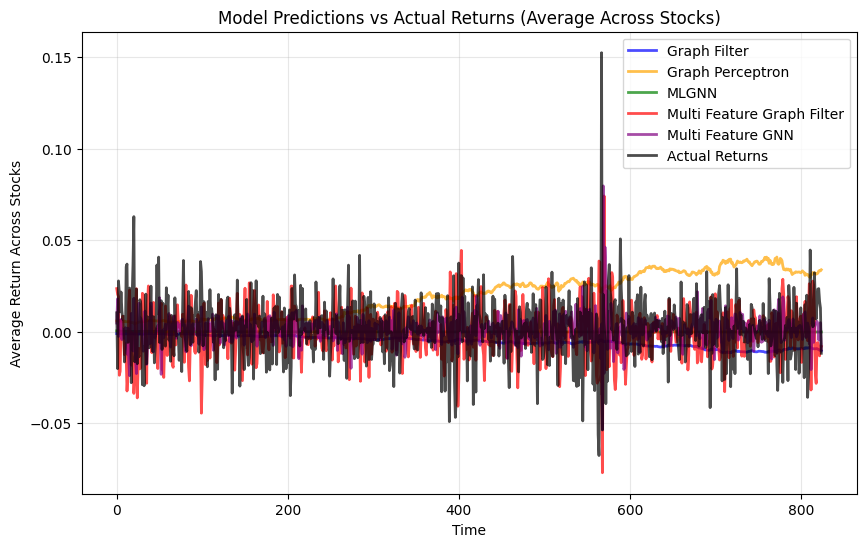

In [ ]:
# Optional: plot deltas vs baseline
plt.figure(figsize=(10, 6))
plt.plot(gf_pred.mean(dim=1).numpy(), label='Graph Filter', linewidth=2, alpha=0.7, color='blue')
plt.plot(gp_pred.mean(dim= 1).numpy(), label='Graph Perceptron', linewidth=2, alpha=0.7, color='orange')
plt.plot(mlgnn_pred.mean(dim=1).numpy(), label='MLGNN', linewidth=2, alpha=0.7, color='green')
plt.plot(mfgf_pred.mean(dim=1).numpy(), label='Multi Feature Graph Filter', linewidth=2, alpha=0.7, color='red')
plt.plot(mfgnn_pred.mean(dim=1).numpy(), label='Multi Feature GNN', linewidth=2, alpha=0.7, color='purple')
plt.plot(y_test_tensor.mean(dim=1).numpy(), label='Actual Returns', linewidth=2, alpha=0.7, color='black')
plt.xlabel('Time')
plt.ylabel('Average Return Across Stocks')
plt.title('Model Predictions vs Actual Returns (Average Across Stocks)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Multi-feature part

This part adds a multi-feature GNN model so that we can see the plan from the presentation: past 5 days, moving-average style features, and volatility. 

In [ ]:
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std


In [ ]:

# -----------------------------
# Multi-feature GNN model
# -----------------------------
class MultiFeatureGraphFilter(nn.Module):
    def __init__(self, gso, in_features, k, hidden_dim=16, activation=nn.ReLU()):
        super().__init__()
        self.gso = torch.tensor(gso, dtype=torch.float32) if not torch.is_tensor(gso) else gso.float()
        self.in_features = in_features
        self.k = k
        self.activation = activation

        # One k-hop filter per input feature
        self.filter_weights = nn.Parameter(torch.empty(in_features, k))
        nn.init.xavier_uniform_(self.filter_weights)

        # Mix features node-wise after graph filtering
        self.feature_mixer = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            activation,
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        """
        x: (B, F, N)
        returns: (B, N)
        """
        B, F, N = x.shape
        outputs = []

        for f in range(F):
            xf = x[:, f, :]                          # (B,N)
            yf = filter_function(self.filter_weights[f], self.gso, xf)  # (B,N)
            outputs.append(yf.unsqueeze(1))         # (B,1,N)

        h = torch.cat(outputs, dim=1)               # (B,F,N)
        h = h.permute(0, 2, 1)                      # (B,N,F)
        y = self.feature_mixer(h).squeeze(-1)       # (B,N)
        return y


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    return {
        "mse": float(mse),
        "mae": float(mae),
        "directional_accuracy": float(directional_acc)
    }


def train_and_evaluate_multifeature_model(
    close_df,
    selected_features,
    split_date="2023-01-01",
    lag_days=5,
    ma_windows=(5, 10),
    vol_windows=(5,),
    lr=0.01,
    epochs=300,
    k=3,
    hidden_dim=16
):
    # Build full feature panel
    X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df = train_test_split_panel(
        close_df, split_date=split_date, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    # Select subset of features by name
    feature_idx = [feature_names.index(name) for name in selected_features]
    X_train = X_train[:, feature_idx, :]
    X_test = X_test[:, feature_idx, :]

    # Standardize
    X_train, X_test, _, _ = standardize_panel(X_train, X_test)

    # Graph built from train returns only
    train_returns_df = returns_df.loc[train_dates]
    corr = stock_graph(train_returns_df.dropna().values)
    corr = normalize_graph(corr)
    corr = torch.tensor(corr, dtype=torch.float32)

    # Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

    # Model
    model = MultiFeatureGraphFilter(
        corr, in_features=len(selected_features), k=k, hidden_dim=hidden_dim, activation=nn.ReLU()
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_tensor)
        loss = criterion(pred, Y_train_tensor)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)

    metrics = evaluate_metrics(Y_test_tensor, test_pred)

    return {
        "model": model,
        "train_losses": train_losses,
        "test_pred": test_pred,
        "y_test": Y_test_tensor,
        "metrics": metrics,
        "selected_features": selected_features,
        "test_dates": test_dates
    }


In [ ]:

# -----------------------------
# Feature sets to compare
# -----------------------------
all_close = yf.download(tickers, start="2018-01-01")["Close"].dropna()

feature_sets = {
    "baseline_ret_lag_1": ["ret_lag_1"],
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

results = {}
summary_rows = []

for name, feat_list in feature_sets.items():
    print(f"\nRunning: {name}")
    out = train_and_evaluate_multifeature_model(
        all_close,
        selected_features=feat_list,
        split_date="2023-01-01",
        lag_days=5,
        ma_windows=(5, 10),
        vol_windows=(5,),
        lr=0.01,
        epochs=300,
        k=3,
        hidden_dim=16
    )
    results[name] = out
    summary_rows.append({
        "feature_set": name,
        "num_features": len(feat_list),
        "mse": out["metrics"]["mse"],
        "mae": out["metrics"]["mae"],
        "directional_accuracy": out["metrics"]["directional_accuracy"]
    })

results_df = pd.DataFrame(summary_rows).sort_values("mse").reset_index(drop=True)
print("\n=== Multi-feature comparison ===")
print(results_df)


[*********************100%***********************]  10 of 10 completed



Running: baseline_ret_lag_1

Running: past_5_returns

Running: past_5_plus_ma

Running: past_5_plus_vol

Running: all_features

=== Multi-feature comparison ===
          feature_set  num_features       mse       mae  directional_accuracy
0  baseline_ret_lag_1             1  0.000683  0.017439              0.508000
1        all_features            10  0.000686  0.017652              0.503273
2      past_5_plus_ma             7  0.000691  0.017579              0.512485
3      past_5_returns             5  0.000692  0.017561              0.517697
4     past_5_plus_vol             6  0.000700  0.017746              0.501333


,feature_set,num_features,mse,mae,directional_accuracy
0,baseline_ret_lag_1,1,0.000683,0.017439,0.508000
1,all_features,10,0.000686,0.017652,0.503273
2,past_5_plus_ma,7,0.000691,0.017579,0.512485
3,past_5_returns,5,0.000692,0.017561,0.517697
4,past_5_plus_vol,6,0.000700,0.017746,0.501333


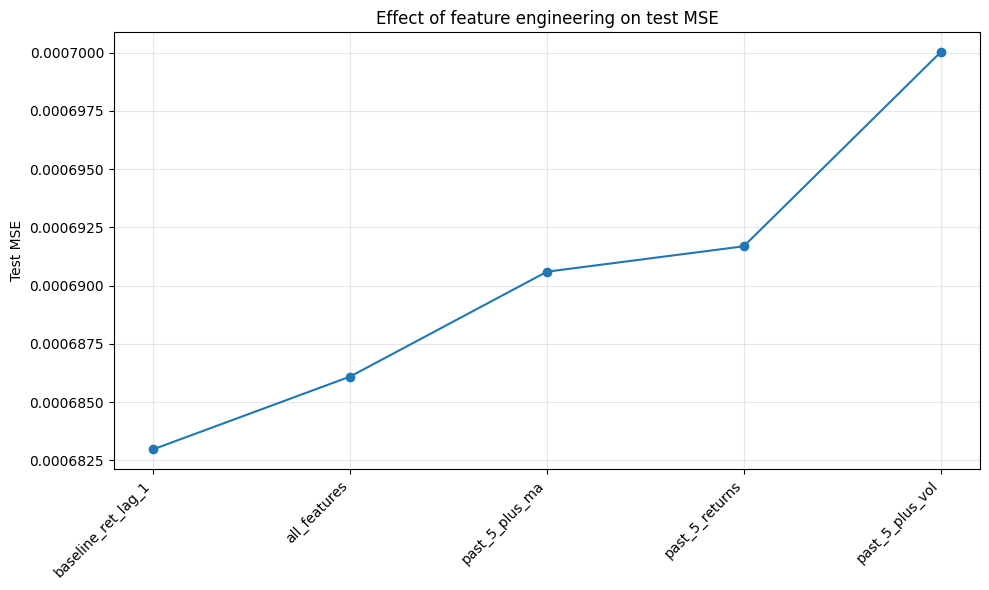

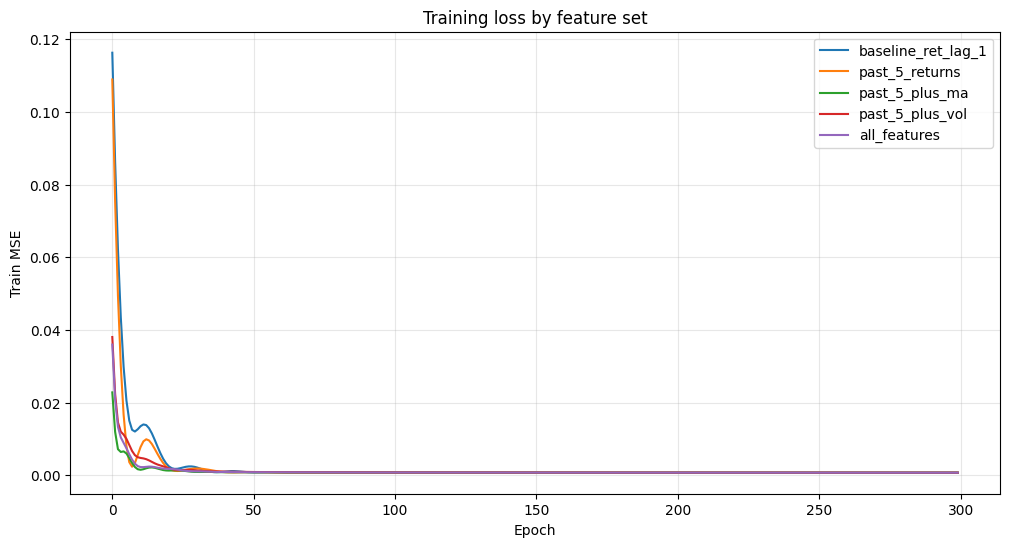

In [ ]:

# Plot comparison table and training curves
display(results_df)

plt.figure(figsize=(10, 6))
plt.plot(results_df["feature_set"], results_df["mse"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test MSE")
plt.title("Effect of feature engineering on test MSE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for name, out in results.items():
    plt.plot(out["train_losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training loss by feature set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Best feature set: baseline_ret_lag_1
['ret_lag_1']
{'mse': 0.0006829725462011993, 'mae': 0.01743929833173752, 'directional_accuracy': 0.508}


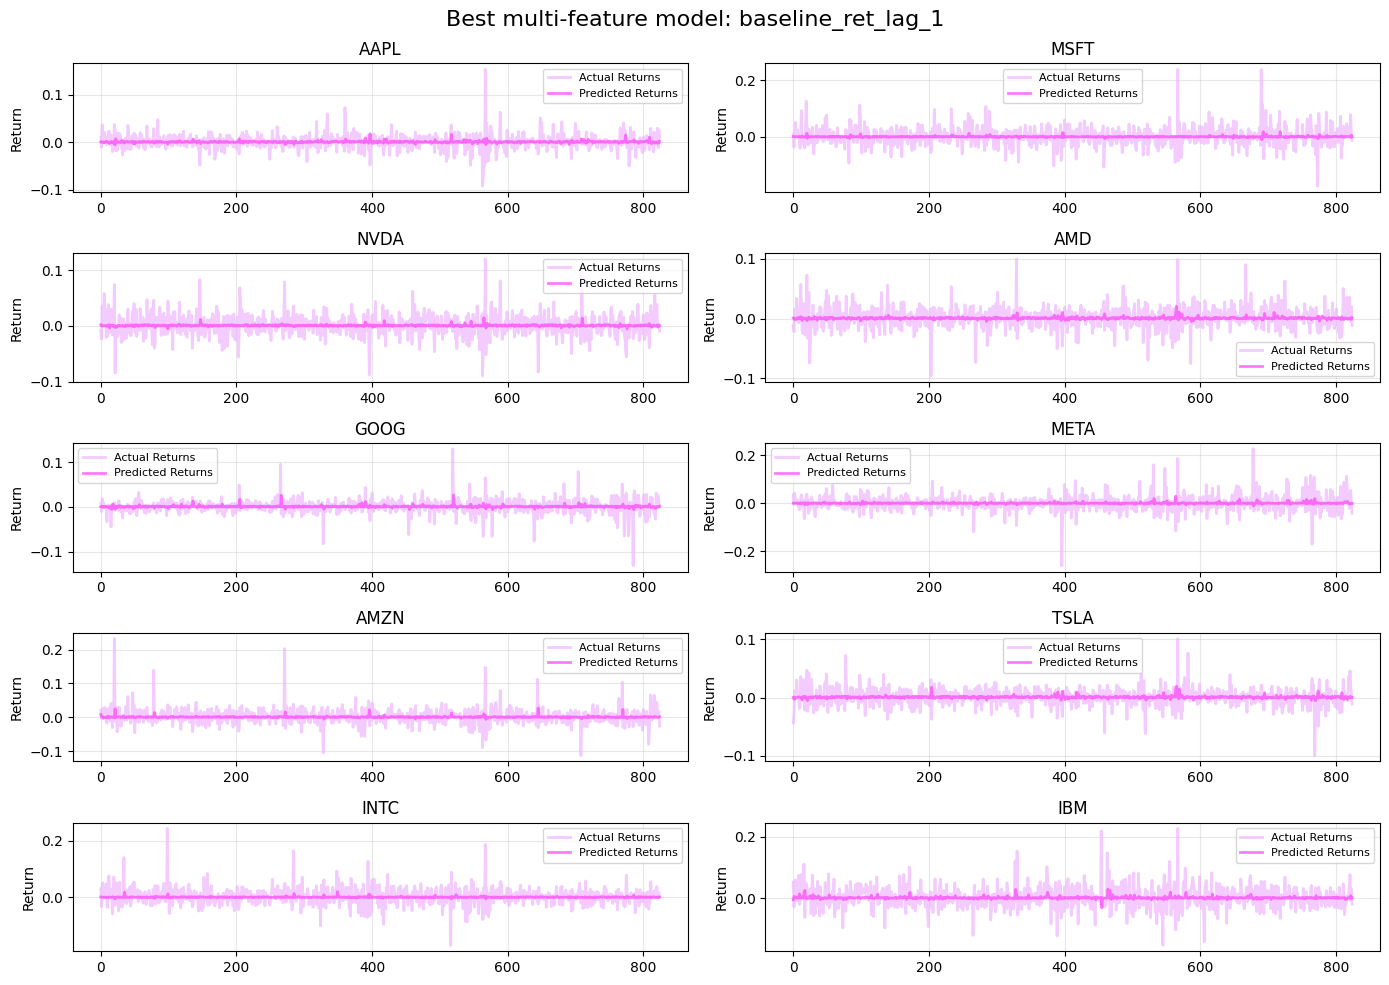

In [ ]:
pink = '#ff42f8' 
purple = '#eeb5ff'  

# Example: inspect best model predictions stock-by-stock
best_name = results_df.iloc[0]["feature_set"]
best_out = results[best_name]

print(f"Best feature set: {best_name}")
print(best_out["selected_features"])
print(best_out["metrics"])

plt.figure(figsize=(14, 10))
plt.suptitle(f"Best multi-feature model: {best_name}", fontsize=16)

best_pred = best_out["test_pred"].detach().cpu().numpy()
best_true = best_out["y_test"].detach().cpu().numpy()

for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i + 1)
    plt.plot(best_true[:, i], label="Actual Returns", linewidth=2, alpha=0.7, color=purple)
    plt.plot(best_pred[:, i], label="Predicted Returns", linewidth=2, alpha=0.7, color=pink)
    plt.title(ticker)
    plt.ylabel("Return")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:

# Optional: direct deltas relative to the simplest baseline
baseline_mse = results["baseline_ret_lag_1"]["metrics"]["mse"]
baseline_mae = results["baseline_ret_lag_1"]["metrics"]["mae"]
baseline_dir = results["baseline_ret_lag_1"]["metrics"]["directional_accuracy"]

delta_df = results_df.copy()
delta_df["mse_change_vs_baseline"] = delta_df["mse"] - baseline_mse
delta_df["mae_change_vs_baseline"] = delta_df["mae"] - baseline_mae
delta_df["dir_acc_change_vs_baseline"] = delta_df["directional_accuracy"] - baseline_dir

print(delta_df.sort_values("mse_change_vs_baseline"))
display(delta_df.sort_values("mse_change_vs_baseline"))


          feature_set  num_features       mse       mae  directional_accuracy  \
0  baseline_ret_lag_1             1  0.000683  0.017439              0.508000   
1        all_features            10  0.000686  0.017652              0.503273   
2      past_5_plus_ma             7  0.000691  0.017579              0.512485   
3      past_5_returns             5  0.000692  0.017561              0.517697   
4     past_5_plus_vol             6  0.000700  0.017746              0.501333   

   mse_change_vs_baseline  mae_change_vs_baseline  dir_acc_change_vs_baseline  
0                0.000000                0.000000                    0.000000  
1                0.000003                0.000213                   -0.004727  
2                0.000008                0.000140                    0.004485  
3                0.000009                0.000121                    0.009697  
4                0.000017                0.000307                   -0.006667  


,feature_set,num_features,mse,mae,directional_accuracy,mse_change_vs_baseline,mae_change_vs_baseline,dir_acc_change_vs_baseline
0,baseline_ret_lag_1,1,0.000683,0.017439,0.508000,0.000000,0.000000,0.000000
1,all_features,10,0.000686,0.017652,0.503273,0.000003,0.000213,-0.004727
2,past_5_plus_ma,7,0.000691,0.017579,0.512485,0.000008,0.000140,0.004485
3,past_5_returns,5,0.000692,0.017561,0.517697,0.000009,0.000121,0.009697
4,past_5_plus_vol,6,0.000700,0.017746,0.501333,0.000017,0.000307,-0.006667
